# Sign Language Video Recognition Assignment

**Corpus Link:** [https://github.com/ye-kyaw-thu/MSL4Emergency](https://github.com/ye-kyaw-thu/MSL4Emergency)  
**Date:** 21 May 2026  
**Tutorial:** for AI (Fundamental) Class Students   
**Author:** Ye Kyaw Thu, Lab. Leader, Language Understanding Lab., Myanmar  

%pwd

## Myanmar Sign Language Corpus Preparation

In [67]:
!ls ./data/ --color=auto

annotations.txt  keypoints          label_map.json    splits.json
augmented        kfold_splits.json  sample4inference  videos


In [68]:
!ls ./data/videos/* | wc

     48      48    1287


In [69]:
!ls ./data/videos/* | head

./data/videos/idx20-10.mp4
./data/videos/idx20-11.mp4
./data/videos/idx20-12.mp4
./data/videos/idx20-13.mp4
./data/videos/idx20-14.mp4
./data/videos/idx20-15.mp4
./data/videos/idx20-16.mp4
./data/videos/idx20-17.mp4
./data/videos/idx20-18.mp4
./data/videos/idx20-19.mp4


In [70]:
!cat ./data/annotations.txt | head -n 30

မီး ။	မီး
မီး ငြှိမ်း ။	မီး ငြှိမ်း
မီးချိတ် ။	မီးချိတ်
မီးကပ် ။	မီးကပ်
ရေပုံး ။	ရေပုံး
သဲ အိတ် ။	အိတ် ထဲ သဲ
မီးသတ်ဆေးဘူး ။	အနီ ဘူး ဖြန်း
မီးသတ်ရေကန် ။	ကန် ထဲ ရေ သိမ်း
မီးလောင် လွယ် သော ပစ္စည်း များ ။	မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး
လောင်စာဆီ ။	ဓာတ်ဆီ 9 2 9 5 အောက်တိန်း အမျိုးမျိုး
အမှိုက် ။	အမှိုက်
လျှပ်စစ် မီး ။	မီး လျှပ်စစ်
ဂက်စ် မီး ။	အဖြူ ဂက်စ်
မီးကြွင်းမီးကျန် ။	မီးကြွင်းမီးကျန်
မီးခလုပ် ။	ခလုပ် နှိပ်
မီးခြစ် ။	မီးခြစ်
ဖယောင်းတိုင် ။	ဖယောင်းတိုင်
ခြင်ဆေးခွေ ။	ခြင် ဆေးခွေ
အမွှေးတိုင် ။	အမွှေးတိုင်
မီးခိုး ။	မီး အခိုးအငွေ့ အမဲ
အောက်စီဂျင် ။	အောက်ဆီဂျင် o 2
ထွက်ပေါက် ။	ဆိုင်းဘုတ် အဲဒီက ပြေး တံခါးပေါက်
မီးသတ်ကား ။	ကား အရေးပေါ် မီးသတ်
မီးသတ်သမား ။	မီးသတ်သမား
မီးသတ်ဌာန ။	မီးသတ် အိမ် ထဲ
လျှပ်စစ် ဝါယာ ရှော့ ။	လျှပ်စစ် ကြိုး ရှော့
ရေဘေး ။	ရေ ကြီး
ဘေးအန္တရာယ် ။	သဘာဝ ဒုက္ခ
မြစ်ခေျာင်း ။	ရေ ချောင်း
မြေနိမ့်ဒေသ ။	မြေနိမ့် အဲ့နေရာ
cat: write error: Broken pipe


## Python Environment

I already run: `source ./venc/bin/activate`

In [71]:
!ls .venv

ls: cannot access '.venv': No such file or directory


## Requirements or Python Libraries

In [72]:
cat requirements.txt

# Myanmar Sign Language Recognition - Dependencies
# Python >= 3.9 recommended
# PyTorch with CUDA 11.8+ (for RTX 3090 Ti)

# Core deep learning
torch>=2.1.0
torchvision>=0.16.0
torchaudio>=2.1.0

# MediaPipe for keypoint extraction
mediapipe>=0.10.7

# Computer vision
opencv-python>=4.8.0

# Scientific computing
numpy>=1.24.0
scipy>=1.11.0
scikit-learn>=1.3.0

# Data handling
pandas>=2.0.0
PyYAML>=6.0

# Visualization
matplotlib>=3.7.0
seaborn>=0.13.0

# Progress bars
tqdm>=4.66.0

# Experiment tracking
tensorboard>=2.14.0

# Metrics
torchmetrics>=1.2.0

# Optional: Weights & Biases (uncomment if desired)
# wandb>=0.16.0


## Python Codes

In [73]:
!ls ./src/*.py

./src/augment.py	 ./src/extract_keypoints.py  ./src/plot_results_v2.py
./src/cross_validate.py  ./src/infer_onnx.py	     ./src/prepare_data.py
./src/dataset.py	 ./src/infer.py		     ./src/train.py
./src/evaluate.py	 ./src/__init__.py	     ./src/utils.py
./src/export_to_onnx.py  ./src/plot_results.py


In [74]:
!ls ./tools/*.py

./tools/lookup_video_label.py  ./tools/probe_mediapipe.py


## Shell Scripts

In [75]:
!ls ./scripts/*.sh --color=auto

./scripts/00_setup_env.sh          ./scripts/06_run_all_experiments.sh
./scripts/01_prepare_data.sh       ./scripts/07_cross_validate.sh
./scripts/02_extract_keypoints.sh  ./scripts/08_infer.sh
./scripts/03_augment_data.sh       ./scripts/09_tensorboard.sh
./scripts/04_train.sh              ./scripts/move_videos.sh
./scripts/05_evaluate.sh


## 01. Prepare Data

In [76]:
from IPython.display import Markdown

# Read the file content
with open('./scripts/01_prepare_data.sh', 'r') as f:
    content = f.read()

# Display it as a highlighted Bash block
display(Markdown(f"```bash\n{content}\n```"))

```bash
#!/usr/bin/env bash
# =============================================================================
# 01_prepare_data.sh  –  Parse annotations, build vocab, create splits
# =============================================================================
# Run ONCE before any training.
# Edit DATA_DIR and ANNOTATION_FILE to match your setup.
# =============================================================================

set -euo pipefail

# ── USER SETTINGS ─────────────────────────────────────────────────────────────
DATA_DIR="data"
VIDEO_DIR="${DATA_DIR}/videos"
ANNOTATION_FILE="${DATA_DIR}/annotations.txt"
CONFIG="config/config.yaml"
LOG_DIR="results/logs"
# ─────────────────────────────────────────────────────────────────────────────

mkdir -p "${LOG_DIR}"

echo "============================================================"
echo " Step 1 — Data Preparation"
echo "============================================================"
echo " Video dir       : ${VIDEO_DIR}"
echo " Annotation file : ${ANNOTATION_FILE}"
echo ""

# Verify annotation file exists
if [[ ! -f "${ANNOTATION_FILE}" ]]; then
    echo "[ERROR] Annotation file not found: ${ANNOTATION_FILE}"
    echo ""
    echo "  Expected format (tab-delimited, one line per sign):"
    echo "  မီးချိတ် ။<TAB>မီးချိတ်"
    echo "  သဲ အိတ် ။<TAB>အိတ် ထဲ သဲ"
    echo ""
    echo "  → Place your annotation file at: ${ANNOTATION_FILE}"
    exit 1
fi

# Verify video directory exists
if [[ ! -d "${VIDEO_DIR}" ]]; then
    echo "[WARNING] Video directory not found: ${VIDEO_DIR}"
    echo "  → Download MSL4Emergency videos from GitHub and place them in ${VIDEO_DIR}"
    echo "  → Continuing with annotation-only preparation…"
fi

# Count videos
N_VIDEOS=$(find "${VIDEO_DIR}" -name "*.mp4" -o -name "*.avi" -o -name "*.mov" \
           -o -name "*.MP4" 2>/dev/null | wc -l || echo 0)
N_ANNS=$(grep -c "." "${ANNOTATION_FILE}" || echo 0)

echo " Found ${N_VIDEOS} videos and ${N_ANNS} annotation lines"
echo ""

# Run preparation
python src/prepare_data.py \
    --config "${CONFIG}" \
    --verify_keypoints \
    2>&1 | tee "${LOG_DIR}/prepare_data.log"

echo ""
echo "============================================================"
echo " Data preparation done!"
echo " Outputs:"
echo "   data/label_map.json   ← class vocab"
echo "   data/splits.json      ← train/val/test indices"
echo "   data/kfold_splits.json← 5-fold CV splits"
echo " Next: run 02_extract_keypoints.sh"
echo "============================================================"

```

In [77]:
!time ./scripts/01_prepare_data.sh

 Step 1 — Data Preparation
 Video dir       : data/videos
 Annotation file : data/annotations.txt

 Found 48 videos and 558 annotation lines

2026-06-17 22:39:15 | INFO     | prepare_data | ============================================================
2026-06-17 22:39:15 | INFO     | prepare_data | MSL Data Preparation
2026-06-17 22:39:15 | INFO     | prepare_data | ============================================================
2026-06-17 22:39:15 | INFO     | prepare_data | Parsing annotation file: data/annotations.txt
2026-06-17 22:39:15 | INFO     | prepare_data | Total annotation records: 558
2026-06-17 22:39:15 | INFO     | prepare_data | Vocabulary built: 556 unique classes
2026-06-17 22:39:15 | INFO     | prepare_data | Label map saved → data/label_map.json
2026-06-17 22:39:15 | INFO     | prepare_data | Matching videos from: data/videos

Dataset Statistics [full]
  Total samples    : 558
  Classes (present): 556 / 556 total
  Samples/class    : min=1, max=2, mean=1.00
  Size distr

In [78]:
!ls ./data/ --color=auto

annotations.txt  keypoints          label_map.json    splits.json
augmented        kfold_splits.json  sample4inference  videos


In [79]:
!cat ./data/label_map.json | head -n 50

{
  "label2idx": {
    "မီး ။": 0,
    "မီး ငြှိမ်း ။": 1,
    "မီးချိတ် ။": 2,
    "မီးကပ် ။": 3,
    "ရေပုံး ။": 4,
    "သဲ အိတ် ။": 5,
    "မီးသတ်ဆေးဘူး ။": 6,
    "မီးသတ်ရေကန် ။": 7,
    "မီးလောင် လွယ် သော ပစ္စည်း များ ။": 8,
    "လောင်စာဆီ ။": 9,
    "အမှိုက် ။": 10,
    "လျှပ်စစ် မီး ။": 11,
    "ဂက်စ် မီး ။": 12,
    "မီးကြွင်းမီးကျန် ။": 13,
    "မီးခလုပ် ။": 14,
    "မီးခြစ် ။": 15,
    "ဖယောင်းတိုင် ။": 16,
    "ခြင်ဆေးခွေ ။": 17,
    "အမွှေးတိုင် ။": 18,
    "မီးခိုး ။": 19,
    "အောက်စီဂျင် ။": 20,
    "ထွက်ပေါက် ။": 21,
    "မီးသတ်ကား ။": 22,
    "မီးသတ်သမား ။": 23,
    "မီးသတ်ဌာန ။": 24,
    "လျှပ်စစ် ဝါယာ ရှော့ ။": 25,
    "ရေဘေး ။": 26,
    "ဘေးအန္တရာယ် ။": 27,
    "မြစ်ခေျာင်း ။": 28,
    "မြေနိမ့်ဒေသ ။": 29,
    "ချိုင့် ။": 30,
    "ရေနုတ်မြောင်း ။": 31,
    "ရေ လွှမ်းမိုး မှု ။": 32,
    "အရေးပေါ် သုံး ပစ္စည်း ။": 33,
    "မိုးလေဝသ သတင်း ။": 34,
    "လျှပ်တစ်ပြက် ရေကြီး ခြင်း ။": 35,
    "ဘေးလွတ် ရာ နေရာ ။": 36,
    "သောက် သုံး ရေ သန့် ။": 37,
    "ကျိုချက် ထား သော 

In [80]:
!cat ./data/splits.json

{
  "train": [
    0,
    2,
    3,
    4,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
    26,
    29,
    31,
    34,
    35,
    37,
    38,
    39,
    41,
    42,
    43,
    45,
    47,
    48,
    49,
    50,
    52,
    53,
    54,
    55,
    59,
    60,
    61,
    62,
    63,
    64,
    65,
    66,
    67,
    68,
    69,
    72,
    74,
    75,
    76,
    77,
    79,
    82,
    84,
    85,
    86,
    88,
    90,
    91,
    92,
    93,
    96,
    97,
    98,
    100,
    101,
    102,
    103,
    105,
    106,
    109,
    110,
    111,
    113,
    115,
    116,
    118,
    120,
    121,
    122,
    123,
    124,
    129,
    130,
    131,
    132,
    133,
    139,
    140,
    141,
    143,
    144,
    145,
    146,
    147,
    149,
    151,
    152,
    153,
    154,
    155,
    156,
    157,
    158,
    160,
    162,
    164,
    165,
    167,
    168,
    169,
    170,
    171,

## 02. Extract Keypoints

ဗီဒီယို ဖိုင်ထဲကနေ MediaPipe library နဲ့ ကီးပွိုင့်တွေကို ဆွဲထုတ်မယ်။ ဒီ process က အချိန်ကြာလိမ့်မယ်။  

In [81]:
from IPython.display import Markdown

# Read the file content
with open('./scripts/02_extract_keypoints.sh', 'r') as f:
    content = f.read()

# Display it as a highlighted Bash block
display(Markdown(f"```bash\n{content}\n```"))

```bash
#!/usr/bin/env bash
# =============================================================================
# 02_extract_keypoints.sh  –  Extract MediaPipe Holistic keypoints from all videos
# =============================================================================
# Processes all .mp4 / .avi / .mov files under data/videos/
# Output .npy files are saved under data/keypoints/ mirroring the folder structure.
#
# For 558 videos on an RTX 3090 Ti this typically takes ~20-40 minutes.
# Re-run safely: already-processed videos are skipped unless --overwrite is set.
# =============================================================================

set -euo pipefail

# ── USER SETTINGS ─────────────────────────────────────────────────────────────
VIDEO_DIR="data/videos"
KEYPOINT_DIR="data/keypoints"
COMPLEXITY=2          # 0=fastest, 2=most accurate (recommended for research)
OVERWRITE=false       # set to true to re-extract existing files
LOG_DIR="results/logs"
# ─────────────────────────────────────────────────────────────────────────────

mkdir -p "${KEYPOINT_DIR}" "${LOG_DIR}"

echo "============================================================"
echo " Step 2 — MediaPipe Holistic Keypoint Extraction"
echo "============================================================"
echo " Video dir     : ${VIDEO_DIR}"
echo " Output dir    : ${KEYPOINT_DIR}"
echo " Complexity    : ${COMPLEXITY}"
echo " Overwrite     : ${OVERWRITE}"
echo ""

if [[ ! -d "${VIDEO_DIR}" ]]; then
    echo "[ERROR] Video directory not found: ${VIDEO_DIR}"
    exit 1
fi

N_VIDEOS=$(find "${VIDEO_DIR}" -type f \( -name "*.mp4" -o -name "*.avi" \
           -o -name "*.mov" -o -name "*.mkv" -o -name "*.MP4" \) | wc -l)
echo " Total videos  : ${N_VIDEOS}"
echo ""

# Build args
EXTRA_ARGS=""
if [[ "${OVERWRITE}" == "true" ]]; then
    EXTRA_ARGS="--overwrite"
fi

# Run extraction
python src/extract_keypoints.py \
    --video_dir  "${VIDEO_DIR}" \
    --output_dir "${KEYPOINT_DIR}" \
    --complexity "${COMPLEXITY}" \
    ${EXTRA_ARGS} \
    --log_file   "${LOG_DIR}/extract_keypoints.log" \
    2>&1 | tee "${LOG_DIR}/extract_keypoints_stdout.log"

echo ""
echo "============================================================"
echo " Keypoint extraction complete!"
echo " Stats saved → ${KEYPOINT_DIR}/extraction_stats.json"
echo " Next: run 03_augment_data.sh"
echo "============================================================"

```

In [82]:
!./scripts/02_extract_keypoints.sh

 Step 2 — MediaPipe Holistic Keypoint Extraction
 Video dir     : data/videos
 Output dir    : data/keypoints
 Complexity    : 2
 Overwrite     : false

 Total videos  : 48

I0000 00:00:1781710756.721989  494311 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1781710756.858687  494365 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 580.159.03), renderer: NVIDIA GeForce RTX 3060/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
I0000 00:00:1781710756.863090  494311 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
W0000 00:00:1781710756.921745  494350 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1781710756.958690  494386 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 580.159.03), renderer: NVIDIA GeForce RTX 3060/PCIe/SSE2
Extracting keypoints: 100%|██████████| 48/48 [00:00<00:00, 4067.61

In [83]:
!ls ./data/ --color=auto

annotations.txt  keypoints          label_map.json    splits.json
augmented        kfold_splits.json  sample4inference  videos


keypoints ဆိုတဲ့ ဖိုလ်ဒါ ရလာပြီ။ အဲဒီဖိုလ်ဒါထဲကို ဝင်ကြည့်ရအောင်။

In [84]:
!ls ./data/keypoints/* | head -n 30

./data/keypoints/extraction_stats.json
./data/keypoints/idx20-10.npy
./data/keypoints/idx20-10_vis.npy
./data/keypoints/idx20-11.npy
./data/keypoints/idx20-11_vis.npy
./data/keypoints/idx20-12.npy
./data/keypoints/idx20-12_vis.npy
./data/keypoints/idx20-13.npy
./data/keypoints/idx20-13_vis.npy
./data/keypoints/idx20-14.npy
./data/keypoints/idx20-14_vis.npy
./data/keypoints/idx20-15.npy
./data/keypoints/idx20-15_vis.npy
./data/keypoints/idx20-16.npy
./data/keypoints/idx20-16_vis.npy
./data/keypoints/idx20-17.npy
./data/keypoints/idx20-17_vis.npy
./data/keypoints/idx20-18.npy
./data/keypoints/idx20-18_vis.npy
./data/keypoints/idx20-19.npy
./data/keypoints/idx20-19_vis.npy
./data/keypoints/idx20-1.npy
./data/keypoints/idx20-1_vis.npy
./data/keypoints/idx20-20.npy
./data/keypoints/idx20-20_vis.npy
./data/keypoints/idx20-21.npy
./data/keypoints/idx20-21_vis.npy
./data/keypoints/idx20-22.npy
./data/keypoints/idx20-22_vis.npy
./data/keypoints/idx20-23.npy


In [85]:
!file ./data/keypoints/idx20-11.npy

./data/keypoints/idx20-11.npy: NumPy array, version 1.0, header length 118


In [86]:
!file ./data/keypoints/idx20-11_vis.npy

./data/keypoints/idx20-11_vis.npy: NumPy array, version 1.0, header length 118


## The Coordinate \& Visibility Data
When extracting keypoints (landmarks) using MediaPipe for applications like Sign Language Recognition, it is standard practice to separate the coordinate data from the metadata (visibility scores).

1. idx20-401.npy (The Coordinate Data)This file likely contains the spatial position of the detected landmarks.

- **What it stores:** For each frame, it stores the $(x, y, z)$ coordinates of the joints (e.g., 33 landmarks for Pose, 21 for Hands).
- **Structure:** This is usually a 3D array with the shape (number_of_frames, number_of_landmarks, 3).
- **Usage:** This is the primary feature vector you feed into your model (e.g., an LSTM, GRU, or Transformer) to classify the sign.

2. idx20-401_vis.npy (The Visibility Data)This file contains the "visibility" scores provided by MediaPipe's underlying machine learning model.
- **What it stores:** A scalar value (usually between 0 and 1) for each landmark, indicating how confident the model is that the landmark is actually visible within the frame.
- **Why it's separate:**
  - **Filtering:** You can use this to mask out unreliable data. For example, if a hand is partially occluded by the body, the visibility score will drop. You might choose to ignore or "zero out" keypoints that fall below a certain threshold to prevent noise from entering your training data.
  - **Weighting:** Advanced models can use these values as "importance weights" to prioritize reliable joints over those that are hidden or poorly tracked.
- **Structure:** Typically matches the frame and landmark count but with only one value per landmark, e.g., (number_of_frames, number_of_landmarks).

In [87]:
import numpy as np

coords = np.load('./data/keypoints/idx20-1.npy')
vis = np.load('./data/keypoints/idx20-1_vis.npy')

print(f"Coordinates shape: {coords.shape}") # Expect: (frames, landmarks, 3)
print(f"Visibility shape: {vis.shape}")     # Expect: (frames, landmarks)

Coordinates shape: (70, 75, 3)
Visibility shape: (70, 33)


In [88]:
import numpy as np

# Load the files
coords = np.load('./data/keypoints/idx20-1.npy')
vis = np.load('./data/keypoints/idx20-1_vis.npy')

# 1. Print Shapes
print(f"--- Shapes ---")
print(f"Coordinates shape: {coords.shape}") 
print(f"Visibility shape:  {vis.shape}")
print("-" * 20)

# 2. Print Data Types
print(f"Coordinates dtype: {coords.dtype}")
print(f"Visibility dtype:  {vis.dtype}")
print("-" * 20)

# 3. Peek at the first frame (first time step)
# This shows you the (x, y, z) for all landmarks in the first frame
print(f"--- Sample Data (First Frame) ---")
print(f"First 3 landmark coordinates:\n{coords[0, :3, :]}") 
print(f"\nFirst 3 visibility scores:\n{vis[0, :3]}")

--- Shapes ---
Coordinates shape: (70, 75, 3)
Visibility shape:  (70, 33)
--------------------
Coordinates dtype: float32
Visibility dtype:  float32
--------------------
--- Sample Data (First Frame) ---
First 3 landmark coordinates:
[[-0.0054413  -1.169925   -1.7945751 ]
 [ 0.05513704 -1.3222133  -1.6365619 ]
 [ 0.09960178 -1.317802   -1.6388329 ]]

First 3 visibility scores:
[0.9930696  0.980853   0.97762257]


**./data/keypoints/extraction_stats.json ကိုလည်း လေ့လာရအောင်**

In [89]:
cat ./data/keypoints/extraction_stats.json

{
  "total": 48,
  "processed": 0,
  "failed": 0,
  "skipped": 48,
  "seq_len_min": 70,
  "seq_len_max": 244,
  "seq_len_mean": 114.95833333333333,
  "seq_len_std": 35.65106259130138,
  "seq_len_p50": 109.5,
  "seq_len_p95": 192.89999999999998,
  "lh_mean_presence": 0.0,
  "rh_mean_presence": 0.0
}

## 03. Augment Data

Video ဖိုင်တစ်ဖိုင် သို့မဟုတ် class တစ်ခုစီအတွက် augment တစ်ခုစီပဲ လုပ်ထားပါတယ်။  

In [90]:
from IPython.display import Markdown

# Read the file content
with open('./scripts/03_augment_data.sh', 'r') as f:
    content = f.read()

# Display it as a highlighted Bash block
display(Markdown(f"```bash\n{content}\n```"))

```bash
#!/usr/bin/env bash
# =============================================================================
# 03_augment_data.sh  –  All-class augmentation for 1-sample-per-class MSL data
# =============================================================================
#
# KEY DESIGN: With 558 videos and ~556 unique classes, a train/val/test split
# produces ZERO class overlap — making evaluation permanently 0%.
#
# Correct fix: augment ALL 558 videos and split BY AUGMENTATION TYPE:
#   Train : aug copies 1..N-1   (all classes, N-1 augmented copies each)
#   Val   : aug copy  0          (all classes, 1 augmented copy each)
#   Test  : original .npy        (all classes, 1 original each = strictest eval)
#
# Result: 100% class overlap across train/val/test.
# =============================================================================

set -euo pipefail

CONFIG="config/config.yaml"
AUG_FACTOR=20
FORCE=false
LOG_DIR="results/logs"
MANIFEST="data/augmented/augmented_manifest.json"

# Parse optional --force flag
for arg in "$@"; do
    [[ "$arg" == "--force" ]] && FORCE=true
done

mkdir -p "data/augmented" "${LOG_DIR}"

echo "============================================================"
echo " Step 3 — All-Class Offline Data Augmentation"
echo "============================================================"
echo " Strategy    : all 558 videos → train/val/test by aug type"
echo " Aug factor  : ${AUG_FACTOR}x"
echo "   Train     : $(( AUG_FACTOR - 1 )) aug copies × 558 = $(( (AUG_FACTOR-1)*558 )) samples"
echo "   Val       : 1 aug copy × 558 = 558 samples"
echo "   Test      : 558 originals (no augmentation)"
echo " Class overlap: 100% across all splits"
echo ""

if [[ -f "${MANIFEST}" && "${FORCE}" != "true" ]]; then
    # Check if it's the new dict format with train/val/test keys
    FORMAT=$(python3 -c "
import json
d = json.load(open('${MANIFEST}'))
print('new' if isinstance(d, dict) and 'train' in d else 'old')
")
    if [[ "${FORMAT}" == "new" ]]; then
        N_TRAIN=$(python3 -c "import json; d=json.load(open('${MANIFEST}')); print(len(d['train']))")
        N_VAL=$(python3 -c "import json; d=json.load(open('${MANIFEST}')); print(len(d['val']))")
        N_TEST=$(python3 -c "import json; d=json.load(open('${MANIFEST}')); print(len(d['test']))")
        echo " [SKIP] All-class manifest exists:"
        echo "   train=${N_TRAIN}, val=${N_VAL}, test=${N_TEST}"
        echo "   Use --force to regenerate."
        exit 0
    else
        echo " [INFO] Old manifest format detected — regenerating with all-class design..."
        rm -f "${MANIFEST}"
    fi
fi

python src/augment.py \
    --config     "${CONFIG}" \
    --aug_factor "${AUG_FACTOR}" \
    2>&1 | tee "${LOG_DIR}/augment.log"

echo ""
echo "============================================================"
echo " Augmentation done!  Manifest → ${MANIFEST}"
echo " Next: bash scripts/04_train.sh"
echo "============================================================"


```

**တကယ်တမ်း Data augmentation လုပ်ပေးမယ့် Python code ကိုလည်း ဝင်လေ့လာကြရအောင်။**  

In [91]:
from IPython.display import Markdown

file_path = './src/augment.py'

with open(file_path, 'r') as f:
    code = f.read()

# 'python' keyword triggers the syntax highlighter
display(Markdown(f"```python\n{code}\n```"))

```python
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
augment.py - Keypoint-space data augmentation for MSL Recognition

Correct experimental design for 1-sample-per-class datasets
─────────────────────────────────────────────────────────────
With 558 videos and ~556 unique classes, a random train/val/test split
produces ZERO class overlap between splits — making val/test accuracy
permanently 0% (the model is asked to classify classes it never trained on).

The correct approach:
  For each of the 558 original videos, generate aug_factor augmented copies.
  Then split BY AUGMENTATION TYPE, not by sample:

    Train  : aug copies 1..aug_factor-1  (all 558 classes, many copies)
    Val    : aug copy   0                 (all 558 classes, 1 aug copy each)
    Test   : the original .npy            (all 558 classes, 1 original each)

  Result: 100% class overlap across all three splits.
  The final test evaluates on REAL original keypoints — the strictest test.

Augmentation strategies (10 total)
────────────────────────────────────
 1. GaussianNoise      - coordinate jitter
 2. TimeWarp           - non-linear temporal warp via cubic spline
 3. HorizontalFlip     - mirror x + swap L/R hand blocks
 4. SpeedPerturbation  - resample to random speed factor
 5. FrameDropout       - randomly drop frames then restore length
 6. SpatialRotate      - 2-D rotation in x-y plane
 7. JointMask          - zero-out random joints (occlusion simulation)
 8. ScaleJitter        - global scale perturbation
 9. TemporalShift      - circular time shift
10. CombinedRandom     - random subset of the above
"""

import argparse
import json
import random
from pathlib import Path
from typing import List, Optional

import numpy as np
from scipy.interpolate import CubicSpline
from tqdm import tqdm

# ─── Node layout ──────────────────────────────────────────────────────────────

POSE_N           = 33
HAND_N           = 21
LEFT_HAND_START  = POSE_N           # 33
RIGHT_HAND_START = POSE_N + HAND_N  # 54

POSE_MIRROR_PAIRS = [
    (1,4),(2,5),(3,6),(7,8),(9,10),
    (11,12),(13,14),(15,16),(17,18),(19,20),(21,22),
    (23,24),(25,26),(27,28),(29,30),(31,32),
]


# ─── Individual augmentations ─────────────────────────────────────────────────

def augment_gaussian_noise(seq: np.ndarray, std: float = 0.008) -> np.ndarray:
    return (seq + np.random.normal(0, std, seq.shape)).astype(np.float32)


def augment_time_warp(seq: np.ndarray, sigma: float = 0.15, knot: int = 4) -> np.ndarray:
    T = seq.shape[0]
    if T < 4:
        return seq
    orig_steps = np.linspace(0, T - 1, num=knot + 2)
    warp_steps = orig_steps + np.random.normal(0, sigma * T, orig_steps.shape)
    warp_steps[0]  = 0
    warp_steps[-1] = T - 1
    warp_steps     = np.clip(warp_steps, 0, T - 1)
    warp_steps     = np.sort(warp_steps)
    # Enforce strictly increasing (CubicSpline requirement)
    eps = 1e-4
    for i in range(1, len(warp_steps)):
        if warp_steps[i] <= warp_steps[i - 1]:
            warp_steps[i] = warp_steps[i - 1] + eps
    if warp_steps[-1] > T - 1:
        return seq.copy()
    cs         = CubicSpline(warp_steps, orig_steps)
    new_steps  = np.linspace(0, T - 1, T)
    orig_times = np.clip(cs(new_steps), 0, T - 1)
    warped = np.zeros_like(seq)
    for j in range(seq.shape[1]):
        for c in range(seq.shape[2]):
            warped[:, j, c] = np.interp(orig_times, np.arange(T), seq[:, j, c])
    return warped.astype(np.float32)


def augment_horizontal_flip(seq: np.ndarray) -> np.ndarray:
    flipped = seq.copy()
    flipped[:, :, 0] = -flipped[:, :, 0]
    for i, j in POSE_MIRROR_PAIRS:
        flipped[:, [i, j], :] = flipped[:, [j, i], :]
    lh = flipped[:, LEFT_HAND_START:LEFT_HAND_START+HAND_N, :].copy()
    rh = flipped[:, RIGHT_HAND_START:RIGHT_HAND_START+HAND_N, :].copy()
    flipped[:, LEFT_HAND_START:LEFT_HAND_START+HAND_N, :]  = rh
    flipped[:, RIGHT_HAND_START:RIGHT_HAND_START+HAND_N, :] = lh
    return flipped.astype(np.float32)


def augment_speed_perturbation(seq: np.ndarray,
                                min_factor: float = 0.75,
                                max_factor: float = 1.35) -> np.ndarray:
    T      = seq.shape[0]
    factor = np.random.uniform(min_factor, max_factor)
    new_T  = max(4, int(round(T / factor)))
    idx    = np.linspace(0, T - 1, new_T)
    out    = np.zeros((new_T, seq.shape[1], seq.shape[2]), dtype=np.float32)
    for j in range(seq.shape[1]):
        for c in range(seq.shape[2]):
            out[:, j, c] = np.interp(idx, np.arange(T), seq[:, j, c])
    return out


def augment_frame_dropout(seq: np.ndarray, max_drop_ratio: float = 0.10) -> np.ndarray:
    T    = seq.shape[0]
    drop = max(1, int(T * np.random.uniform(0, max_drop_ratio)))
    keep = sorted(random.sample(range(T), T - drop))
    kept = seq[keep]
    idx  = np.round(np.linspace(0, len(keep) - 1, T)).astype(int)
    return kept[idx].astype(np.float32)


def augment_spatial_rotate(seq: np.ndarray, max_angle_deg: float = 12.0) -> np.ndarray:
    angle = np.radians(np.random.uniform(-max_angle_deg, max_angle_deg))
    c, s  = np.cos(angle), np.sin(angle)
    rot   = np.array([[c, -s], [s, c]], dtype=np.float32)
    out   = seq.copy()
    out[:, :, :2] = np.einsum('ij,tnj->tni', rot, seq[:, :, :2])
    return out.astype(np.float32)


def augment_joint_mask(seq: np.ndarray, max_mask_ratio: float = 0.10) -> np.ndarray:
    N       = seq.shape[1]
    n_mask  = max(1, int(N * np.random.uniform(0, max_mask_ratio)))
    indices = random.sample(range(N), n_mask)
    out     = seq.copy()
    out[:, indices, :] = 0.0
    return out.astype(np.float32)


def augment_scale_jitter(seq: np.ndarray,
                          min_scale: float = 0.85,
                          max_scale: float = 1.15) -> np.ndarray:
    return (seq * np.random.uniform(min_scale, max_scale)).astype(np.float32)


def augment_temporal_shift(seq: np.ndarray, max_shift: int = 5) -> np.ndarray:
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(seq, shift, axis=0).astype(np.float32)


# ─── Combined random augmentor ─────────────────────────────────────────────────

class RandomAugmentor:
    """Apply a random subset of augmentations; each with its own probability."""

    def __init__(self, cfg: dict):
        self.cfg = cfg

    def _p(self, key: str) -> float:
        return self.cfg.get(key, {}).get('prob', 0.0)

    def __call__(self, seq: np.ndarray) -> np.ndarray:
        aug = seq.copy()

        if random.random() < self._p('gaussian_noise'):
            aug = augment_gaussian_noise(aug, std=self.cfg['gaussian_noise'].get('std', 0.008))

        if random.random() < self._p('time_warp'):
            aug = augment_time_warp(aug,
                sigma=self.cfg['time_warp'].get('sigma', 0.15),
                knot =self.cfg['time_warp'].get('knot',  4))

        if random.random() < self._p('horizontal_flip'):
            aug = augment_horizontal_flip(aug)

        if random.random() < self._p('speed_perturbation'):
            sp  = self.cfg['speed_perturbation']
            aug = augment_speed_perturbation(aug,
                min_factor=sp.get('min_factor', 0.75),
                max_factor=sp.get('max_factor', 1.35))

        if random.random() < self._p('frame_dropout'):
            aug = augment_frame_dropout(aug,
                max_drop_ratio=self.cfg['frame_dropout'].get('max_drop_ratio', 0.10))

        if random.random() < self._p('spatial_rotate'):
            aug = augment_spatial_rotate(aug,
                max_angle_deg=self.cfg['spatial_rotate'].get('max_angle', 12))

        if random.random() < self._p('joint_mask'):
            aug = augment_joint_mask(aug,
                max_mask_ratio=self.cfg['joint_mask'].get('max_mask_ratio', 0.10))

        if random.random() < self._p('scale_jitter'):
            sj  = self.cfg['scale_jitter']
            aug = augment_scale_jitter(aug,
                min_scale=sj.get('min_scale', 0.85),
                max_scale=sj.get('max_scale', 1.15))

        if random.random() < self._p('temporal_shift'):
            aug = augment_temporal_shift(aug,
                max_shift=self.cfg['temporal_shift'].get('max_shift', 5))

        return aug


# ─── Main augmentation pipeline (correct design for 1-sample-per-class) ───────

def augment_dataset_all_classes(
    keypoint_dir: str,
    output_dir:   str,
    records:      list,       # ALL 558 matched records
    label2idx:    dict,
    aug_factor:   int  = 20,  # total augmented copies per original
    aug_cfg:      dict = None,
    seed:         int  = 42,
) -> dict:
    """
    Correct augmentation strategy for datasets with 1 sample per class.

    For EACH of the 558 original videos:
      - aug_000  → val split   (1 augmented copy, realistic noise)
      - aug_001 .. aug_{N-1} → train split  (N-1 augmented copies)
      - original .npy         → test split  (real, un-augmented)

    This guarantees 100% class overlap across all three splits.

    Returns:
        dict with keys 'train', 'val', 'test', each a list of record dicts.
        Also saves augmented_manifest.json in output_dir.
    """
    random.seed(seed)
    np.random.seed(seed)

    output_dir = Path(output_dir)
    train_dir  = output_dir / 'train'
    val_dir    = output_dir / 'val'
    train_dir.mkdir(parents=True, exist_ok=True)
    val_dir.mkdir(parents=True, exist_ok=True)

    augmentor = RandomAugmentor(aug_cfg) if aug_cfg else None

    train_records = []
    val_records   = []
    test_records  = []   # points to original keypoint files

    missing = 0
    for rec in tqdm(records, desc="Augmenting all classes", unit="sign"):
        kp_path = rec.get('keypoint_path')
        if not kp_path or not Path(kp_path).exists():
            missing += 1
            continue

        seq   = np.load(kp_path).astype(np.float32)  # (T, 75, 3)
        idx   = rec['idx']
        label = rec['label']

        # ── Test: original keypoint (no augmentation) ─────────────────────
        test_records.append({
            **rec,
            'keypoint_path': kp_path,
            'is_augmented':  False,
            'split':         'test',
        })

        # ── Val: first augmented copy (aug_000) ───────────────────────────
        aug0_path = val_dir / f"{idx:04d}_aug000.npy"
        aug0      = augmentor(seq) if augmentor else seq.copy()
        np.save(str(aug0_path), aug0)
        val_records.append({
            **rec,
            'keypoint_path': str(aug0_path),
            'is_augmented':  True,
            'aug_id':        0,
            'split':         'val',
        })

        # ── Train: aug_001 .. aug_{aug_factor-1} ─────────────────────────
        for aug_i in range(1, aug_factor):
            aug_path = train_dir / f"{idx:04d}_aug{aug_i:03d}.npy"
            aug_seq  = augmentor(seq) if augmentor else seq.copy()
            np.save(str(aug_path), aug_seq)
            train_records.append({
                **rec,
                'keypoint_path': str(aug_path),
                'is_augmented':  True,
                'aug_id':        aug_i,
                'split':         'train',
            })

    if missing:
        print(f"[WARNING] {missing} records had no keypoint file and were skipped.")

    manifest = {
        'train': train_records,
        'val':   val_records,
        'test':  test_records,
    }

    manifest_path = output_dir / 'augmented_manifest.json'
    with open(manifest_path, 'w', encoding='utf-8') as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)

    print(f"\n{'='*60}")
    print("  Augmentation Complete (all-class design)")
    print(f"{'='*60}")
    print(f"  Original videos   : {len(records)}")
    print(f"  Aug factor        : {aug_factor}  (train uses {aug_factor-1}, val uses 1)")
    print(f"  Train samples     : {len(train_records)}  (augmented, all classes)")
    print(f"  Val   samples     : {len(val_records)}   (augmented, all classes)")
    print(f"  Test  samples     : {len(test_records)}   (original,  all classes)")
    print(f"  Class overlap     : 100% across all splits")
    print(f"  Manifest          : {manifest_path}")
    print(f"{'='*60}\n")

    return manifest


# ─── CLI ──────────────────────────────────────────────────────────────────────

def main():
    import yaml
    import sys
    sys.path.insert(0, str(Path(__file__).parent))
    from utils import (parse_annotation_file, build_label_vocabulary,
                       match_videos_to_annotations, get_logger)

    parser = argparse.ArgumentParser(
        description="MSL keypoint augmentation (all-class design for 1-sample-per-class datasets)"
    )
    parser.add_argument('--config',      required=True)
    parser.add_argument('--aug_factor',  type=int, default=None)
    args = parser.parse_args()

    with open(args.config) as f:
        cfg = yaml.safe_load(f)

    dcfg = cfg['data']
    acfg = cfg['augmentation']
    if args.aug_factor:
        acfg['aug_factor'] = args.aug_factor

    records              = parse_annotation_file(dcfg['annotation_file'])
    label2idx, idx2label = build_label_vocabulary(records)
    records              = match_videos_to_annotations(
        dcfg['video_dir'], records, dcfg['keypoint_dir']
    )

    augment_dataset_all_classes(
        keypoint_dir = dcfg['keypoint_dir'],
        output_dir   = dcfg['augmented_dir'],
        records      = records,
        label2idx    = label2idx,
        aug_factor   = acfg.get('aug_factor', 20),
        aug_cfg      = acfg,
        seed         = dcfg.get('seed', 42),
    )


if __name__ == '__main__':
    main()


```

### Data Augmentation Process Overview

Code ကိုဖတ်နိုင်တဲ့ ကျောင်းသားတွေကလည်း code ကနေတဆင့်လေ့လာပါ။ Code ဖတ်ဖို့ အခက်အခဲရှိတဲ့ ကျောင်းသားတွေကလည်း အနည်းဆုံး ဘယ်လို data augmentation လုပ်သွားတယ် ဆိုတာကို အောက်ပါ overview ပုံကနေတဆင့် လေ့လာသွားကြပါ။  

In [92]:
from IPython.display import Image, display

# Replace this path if your file is in a different subdirectory
#image_path = './fig/augment.py.dot.png'

#display(Image(filename=image_path))

ဒီ experiment မှာ data augmentation process က အရေးကြီးတယ်။ တကယ်တမ်း နားလည်ဖို့က Python code ရော Shell script ကိုရော တွဲကြည့်မှ ဖြစ်လိမ့်မယ်။ Training, Validation အတွက်ကို data augmentation လုပ်ထားတဲ့ ဒေတာကိုပဲ သုံးပြီးတော့ Testing အပိုင်းကျမှ အော်ရဂျင်နယ် ဗီဒီယိုနဲ့ စမ်းတာမို့လို့။   

### The Data Augmentation Process

The process follows a specific "All-Class" design to ensure that all 558 classes appear in every data split.
- *Training Set:* Contains 19 augmented copies (indices aug001 through aug019) per original video, totaling $558 \times 19$ samples.
- *Validation Set:* Contains exactly 1 augmented copy (index aug000) per original video, totaling $558$ samples.
- *Testing Set:* Uses the 558 original .npy files directly, ensuring the final performance evaluation is based on un-altered data.

In [93]:
from IPython.display import Image, display

# Replace this path if your file is in a different subdirectory
image_path = './fig/03_augment_data.sh.dot.png'

display(Image(filename=image_path))

FileNotFoundError: [Errno 2] No such file or directory: './fig/03_augment_data.sh.dot.png'

**Data augmentation လုပ်ခိုင်းမယ်။**  

In [ ]:
!time ./scripts/03_augment_data.sh

 Step 3 — All-Class Offline Data Augmentation
 Strategy    : all 558 videos → train/val/test by aug type
 Aug factor  : 20x
   Train     : 19 aug copies × 558 = 10602 samples
   Val       : 1 aug copy × 558 = 558 samples
   Test      : 558 originals (no augmentation)
 Class overlap: 100% across all splits

Augmenting all classes: 100%|██████████| 558/558 [00:02<00:00, 255.35sign/s]
[WARNING] 510 records had no keypoint file and were skipped.

  Augmentation Complete (all-class design)
  Original videos   : 558
  Aug factor        : 20  (train uses 19, val uses 1)
  Train samples     : 912  (augmented, all classes)
  Val   samples     : 48   (augmented, all classes)
  Test  samples     : 48   (original,  all classes)
  Class overlap     : 100% across all splits
  Manifest          : data/augmented/augmented_manifest.json


 Augmentation done!  Manifest → data/augmented/augmented_manifest.json
 Next: bash scripts/04_train.sh

real	0m4.300s
user	0m4.915s
sys	0m1.113s


**data augmentation လုပ်ပြီး ထွက်လာတဲ့ ဖိုင်တွေကို တချက် ကြည့်ရအောင်။**   

In [ ]:
!ls ./data/ --color=auto

annotations.txt  keypoints          label_map.json  videos
augmented        kfold_splits.json  splits.json


In [ ]:
!ls ./data/augmented/ --color=auto

augmented_manifest.json  train  val


In [ ]:
!cat ./data/augmented/augmented_manifest.json | head -n 60 

{
  "train": [
    {
      "idx": 0,
      "normal_text": "မီး ။",
      "msl_gloss": "မီး",
      "label": "မီး ။",
      "video_path": "data/videos/idx20-1.mp4",
      "keypoint_path": "data/augmented/train/0000_aug001.npy",
      "is_augmented": true,
      "aug_id": 1,
      "split": "train"
    },
    {
      "idx": 0,
      "normal_text": "မီး ။",
      "msl_gloss": "မီး",
      "label": "မီး ။",
      "video_path": "data/videos/idx20-1.mp4",
      "keypoint_path": "data/augmented/train/0000_aug002.npy",
      "is_augmented": true,
      "aug_id": 2,
      "split": "train"
    },
    {
      "idx": 0,
      "normal_text": "မီး ။",
      "msl_gloss": "မီး",
      "label": "မီး ။",
      "video_path": "data/videos/idx20-1.mp4",
      "keypoint_path": "data/augmented/train/0000_aug003.npy",
      "is_augmented": true,
      "aug_id": 3,
      "split": "train"
    },
    {
      "idx": 0,
      "normal_text": "မီး ။",
      "msl_gloss": "မီး",
      "label": "မီး ။",
      "video_pat

In [ ]:
!cat ./data/augmented/augmented_manifest.json | tail -n 60 

      "normal_text": "ဆည် ။",
      "msl_gloss": "ရေ ဆည်",
      "label": "ဆည် ။",
      "video_path": "data/videos/idx20-43.mp4",
      "keypoint_path": "data/keypoints/idx20-43.npy",
      "is_augmented": false,
      "split": "test"
    },
    {
      "idx": 43,
      "normal_text": "ရေလှောင်တမံ ။",
      "msl_gloss": "ရေ တမံ",
      "label": "ရေလှောင်တမံ ။",
      "video_path": "data/videos/idx20-44.mp4",
      "keypoint_path": "data/keypoints/idx20-44.npy",
      "is_augmented": false,
      "split": "test"
    },
    {
      "idx": 44,
      "normal_text": "ရေလှောင်ကန် ။",
      "msl_gloss": "မာ ကန် အဲ့မှာ ရေ သိမ်းv",
      "label": "ရေလှောင်ကန် ။",
      "video_path": "data/videos/idx20-45.mp4",
      "keypoint_path": "data/keypoints/idx20-45.npy",
      "is_augmented": false,
      "split": "test"
    },
    {
      "idx": 45,
      "normal_text": "တာဝါတိုင် ။",
      "msl_gloss": "ဖုန်း တာဝါတိုင်",
      "label": "တာဝါတိုင် ။",
      "video_path": "data/videos/idx20-46.mp4",
 

In [ ]:
!ls ./data/augmented/train/* | head -n 100

./data/augmented/train/0000_aug001.npy
./data/augmented/train/0000_aug002.npy
./data/augmented/train/0000_aug003.npy
./data/augmented/train/0000_aug004.npy
./data/augmented/train/0000_aug005.npy
./data/augmented/train/0000_aug006.npy
./data/augmented/train/0000_aug007.npy
./data/augmented/train/0000_aug008.npy
./data/augmented/train/0000_aug009.npy
./data/augmented/train/0000_aug010.npy
./data/augmented/train/0000_aug011.npy
./data/augmented/train/0000_aug012.npy
./data/augmented/train/0000_aug013.npy
./data/augmented/train/0000_aug014.npy
./data/augmented/train/0000_aug015.npy
./data/augmented/train/0000_aug016.npy
./data/augmented/train/0000_aug017.npy
./data/augmented/train/0000_aug018.npy
./data/augmented/train/0000_aug019.npy
./data/augmented/train/0001_aug001.npy
./data/augmented/train/0001_aug002.npy
./data/augmented/train/0001_aug003.npy
./data/augmented/train/0001_aug004.npy
./data/augmented/train/0001_aug005.npy
./data/augmented/train/0001_aug006.npy
./data/augmented/train/00

**Validation အတွက်က data augmented လုပ်ထားတဲ့ ဖိုင်တစ်ဖိုင်စီပဲ သုံးမယ်။**  

In [ ]:
!ls ./data/augmented/val/* | head

./data/augmented/val/0000_aug000.npy
./data/augmented/val/0001_aug000.npy
./data/augmented/val/0002_aug000.npy
./data/augmented/val/0003_aug000.npy
./data/augmented/val/0004_aug000.npy
./data/augmented/val/0005_aug000.npy
./data/augmented/val/0006_aug000.npy
./data/augmented/val/0007_aug000.npy
./data/augmented/val/0008_aug000.npy
./data/augmented/val/0009_aug000.npy


## 0.4 Training 

Architecture အနေနဲ့ သုံးမျိုး သုံးခဲ့တယ်။ Bi-LSTM, Transformer ရယ် ပြီးတော့ STGCN (Spatio-Temporal Graph Convolutional Network) ရယ်ပါ။  
Training process overview ကို ပုံအနေနဲ့ ဆွဲပြရရင် အောက်ပါအတိုင်းပါ။  

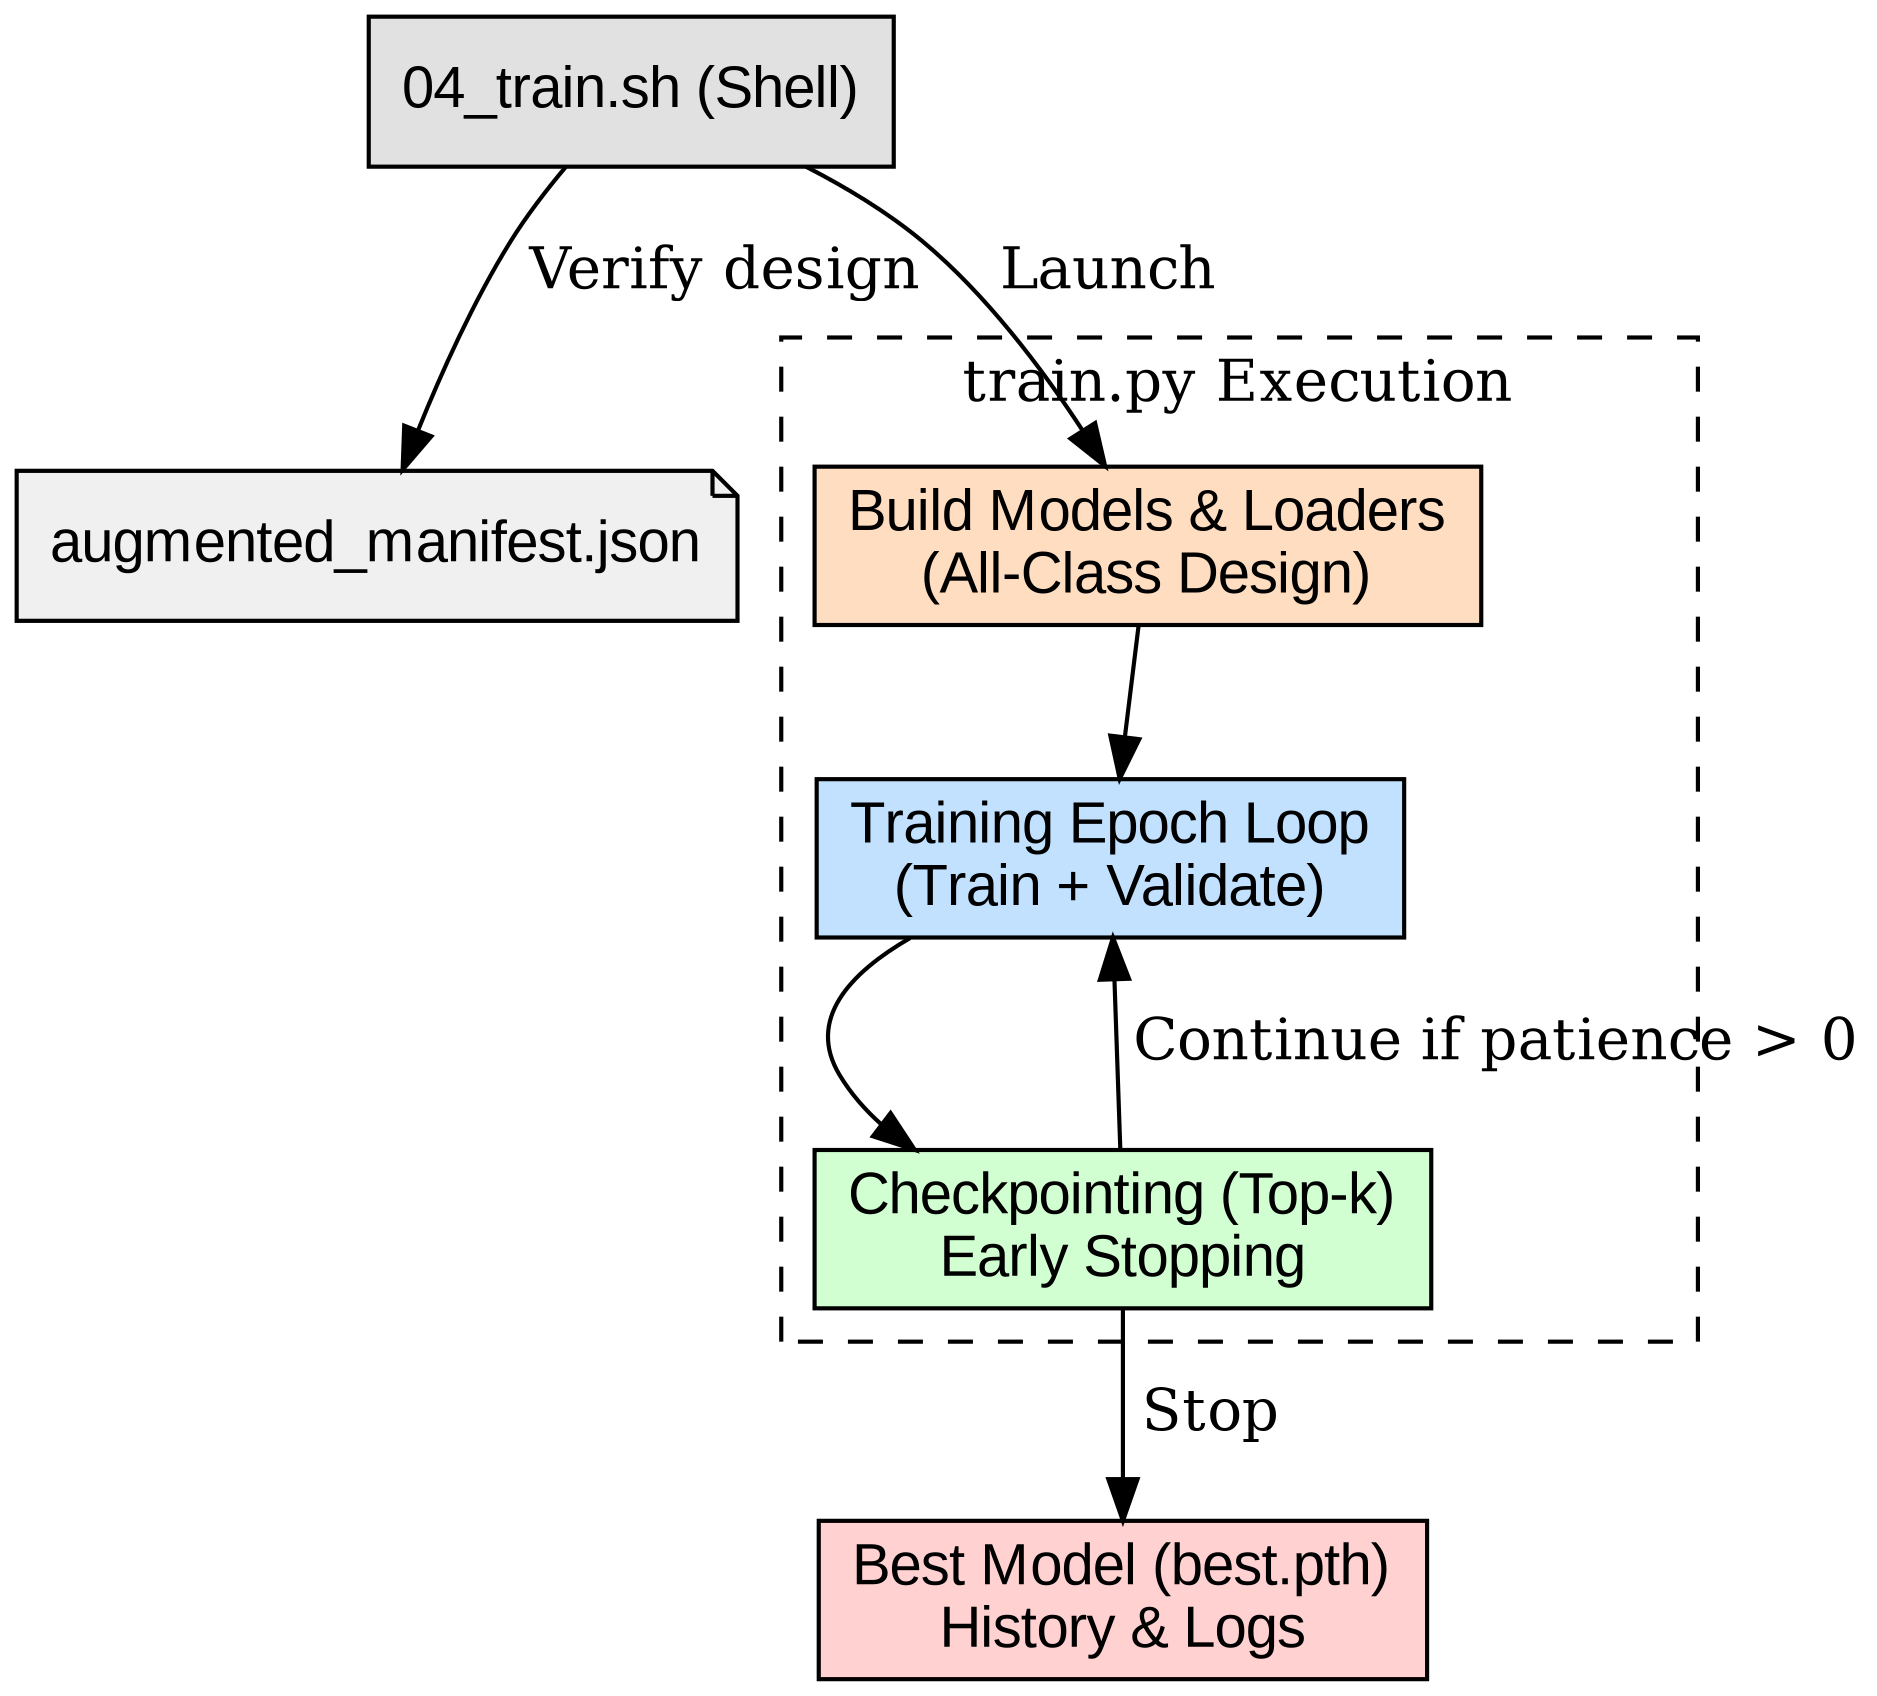

In [ ]:
from IPython.display import Image, display

# Replace this path if your file is in a different subdirectory
image_path = './fig/training_process.dot.png'

display(Image(filename=image_path, width=450, height=200))

In [ ]:
from IPython.display import Markdown

file_path = './src/train.py'

with open(file_path, 'r') as f:
    code = f.read()

# 'python' keyword triggers the syntax highlighter
display(Markdown(f"```python\n{code}\n```"))

```python
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
train.py - Training script for MSL Sign Language Recognition

Features
────────
  - Automatic Mixed Precision (AMP) for RTX 3090 Ti
  - Early stopping with patience
  - Cosine / Step / Plateau LR scheduler
  - TensorBoard logging
  - Label smoothing
  - Class-weighted loss for imbalanced data
  - Top-k checkpoint saving
  - Gradient clipping

Usage
─────
  python src/train.py \
      --config config/config.yaml \
      --model  bilstm \
      --exp    exp01_bilstm
"""

import argparse
import heapq
import json
import os
import sys
import time
from pathlib import Path

import torch
import torch.nn as nn
import yaml
from torch.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter

sys.path.insert(0, str(Path(__file__).parent))
from dataset import build_dataloaders
from models  import build_model
from utils   import (
    get_logger, set_seed, get_device, count_parameters,
    parse_annotation_file, build_label_vocabulary,
    match_videos_to_annotations, load_splits,
    save_label_map, save_checkpoint, compute_class_weights,
)
from augment import RandomAugmentor


# ─── Focal Loss (optional) ────────────────────────────────────────────────────

class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, weight=None, label_smoothing: float = 0.0):
        super().__init__()
        self.gamma   = gamma
        self.weight  = weight
        self.ls      = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = nn.functional.cross_entropy(
            logits, targets, weight=self.weight,
            label_smoothing=self.ls, reduction='none'
        )
        pt  = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()


# ─── Metrics ──────────────────────────────────────────────────────────────────

def compute_accuracy(logits: torch.Tensor, labels: torch.Tensor, top_k=(1, 5)):
    """Compute top-k accuracy."""
    results = {}
    with torch.no_grad():
        max_k = max(top_k)
        batch_size = labels.size(0)
        _, pred = logits.topk(min(max_k, logits.size(1)), dim=1, largest=True, sorted=True)
        pred = pred.t()
        correct = pred.eq(labels.view(1, -1).expand_as(pred))
        for k in top_k:
            if k <= logits.size(1):
                correct_k = correct[:k].reshape(-1).float().sum()
                results[f'top{k}'] = correct_k.item() / batch_size
            else:
                results[f'top{k}'] = 0.0
    return results


# ─── Train / Validate one epoch ───────────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, scaler, device, cfg, logger):
    model.train()
    total_loss = 0.0
    total_top1 = 0.0
    total_top5 = 0.0
    n_batches  = 0
    log_interval = cfg['logging'].get('log_interval', 20)

    for batch_idx, batch in enumerate(loader):
        kp     = batch['keypoints'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)
        mask   = batch['mask'].to(device, non_blocking=True)
        lengths= batch['length'].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg['training']['use_amp']):
            if hasattr(model, 'lstm'):
                logits = model(kp, lengths=lengths, mask=mask)
            elif hasattr(model, 'encoder'):
                logits = model(kp, mask=mask)
            else:
                logits = model(kp)
            loss = criterion(logits, labels)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), cfg['training'].get('grad_clip', 1.0)
        )
        scaler.step(optimizer)
        scaler.update()

        acc = compute_accuracy(logits.detach(), labels)
        total_loss += loss.item()
        total_top1 += acc['top1']
        total_top5 += acc.get('top5', 0.0)
        n_batches  += 1

        if (batch_idx + 1) % log_interval == 0:
            logger.debug(
                f"  batch {batch_idx+1}/{len(loader)}  "
                f"loss={loss.item():.4f}  top1={acc['top1']*100:.1f}%"
            )

    return {
        'loss': total_loss / n_batches,
        'top1': total_top1 / n_batches,
        'top5': total_top5 / n_batches,
    }


@torch.no_grad()
def validate(model, loader, criterion, device, cfg):
    model.eval()
    total_loss = 0.0
    total_top1 = 0.0
    total_top5 = 0.0
    n_batches  = 0

    for batch in loader:
        kp     = batch['keypoints'].to(device, non_blocking=True)
        labels = batch['label'].to(device, non_blocking=True)
        mask   = batch['mask'].to(device, non_blocking=True)
        lengths= batch['length'].to(device, non_blocking=True)

        with autocast('cuda', enabled=cfg['training']['use_amp']):
            if hasattr(model, 'lstm'):
                logits = model(kp, lengths=lengths, mask=mask)
            elif hasattr(model, 'encoder'):
                logits = model(kp, mask=mask)
            else:
                logits = model(kp)
            loss = criterion(logits, labels)

        acc = compute_accuracy(logits, labels)
        total_loss += loss.item()
        total_top1 += acc['top1']
        total_top5 += acc.get('top5', 0.0)
        n_batches  += 1

    return {
        'loss': total_loss / n_batches,
        'top1': total_top1 / n_batches,
        'top5': total_top5 / n_batches,
    }


# ─── Main training loop ───────────────────────────────────────────────────────

def train(args):
    # Config
    with open(args.config) as f:
        cfg = yaml.safe_load(f)

    tcfg = cfg['training']
    dcfg = cfg['data']
    set_seed(tcfg['seed'])

    # Experiment directories
    exp_dir  = Path('results') / args.exp
    ckpt_dir = exp_dir / 'checkpoints'
    log_dir  = exp_dir / 'logs'
    exp_dir.mkdir(parents=True, exist_ok=True)
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    log_dir.mkdir(parents=True, exist_ok=True)

    # Save config snapshot
    with open(exp_dir / 'config_used.yaml', 'w') as f:
        yaml.dump(cfg, f)

    logger = get_logger('train', log_file=str(log_dir / 'train.log'))
    logger.info(f"Experiment: {args.exp}  Model: {args.model}")

    device = get_device()

    # ── Data ──────────────────────────────────────────────────────────────────
    records              = parse_annotation_file(dcfg['annotation_file'])
    label2idx, idx2label = build_label_vocabulary(records)
    num_classes          = len(label2idx)
    logger.info(f"Classes: {num_classes}")

    save_label_map(label2idx, idx2label, dcfg['label_map_file'])

    records = match_videos_to_annotations(
        dcfg['video_dir'], records, dcfg['keypoint_dir']
    )

    # ── Load splits from all-class augmented manifest ─────────────────────────
    # The new design: augmented_manifest.json has keys 'train', 'val', 'test'
    # where ALL 556 classes are present in every split.  This is the only
    # correct approach when there is 1 original video per class.
    aug_manifest_path = Path(dcfg['augmented_dir']) / 'augmented_manifest.json'

    if not aug_manifest_path.exists():
        logger.error(
            f"Augmented manifest not found: {aug_manifest_path}\n"
            "Run:  bash scripts/03_augment_data.sh"
        )
        raise FileNotFoundError(str(aug_manifest_path))

    with open(aug_manifest_path, encoding='utf-8') as f:
        manifest = json.load(f)

    # Support both new dict format {'train':[], 'val':[], 'test':[]}
    # and old flat-list format (legacy, just in case)
    if isinstance(manifest, dict) and 'train' in manifest:
        train_records = manifest['train']
        val_records   = manifest['val']
        test_records  = manifest['test']
        logger.info(
            f"Using all-class manifest: "
            f"train={len(train_records)}, val={len(val_records)}, test={len(test_records)}"
        )
    else:
        # Old flat-list format fallback (pre-fix manifest)
        logger.warning(
            "Old flat manifest format detected. Re-run 03_augment_data.sh "
            "to regenerate with the all-class design."
        )
        train_records = manifest
        splits        = load_splits(dcfg['split_file'])
        val_records   = [records[i] for i in splits['val']]
        test_records  = [records[i] for i in splits['test']]

    # No on-the-fly augmentation needed — training data is already augmented
    augmentor = None

    train_loader, val_loader, test_loader = build_dataloaders(
        train_records, val_records, test_records,
        label2idx, cfg,
        augmentor  = augmentor,
        model_type = args.model,
    )

    # ── Model ─────────────────────────────────────────────────────────────────
    model = build_model(args.model, cfg, num_classes).to(device)
    n_params = count_parameters(model)
    logger.info(f"Model: {args.model}  Params: {n_params:,}")

    # ── Loss ──────────────────────────────────────────────────────────────────
    # All classes have equal aug counts → uniform weights; still pass for API compat
    class_weights = compute_class_weights(
        train_records, label2idx, device
    ) if args.weighted_loss else None

    if tcfg.get('loss', 'cross_entropy') == 'focal':
        criterion = FocalLoss(
            gamma          = tcfg.get('focal_gamma', 2.0),
            weight         = class_weights,
            label_smoothing= tcfg.get('label_smoothing', 0.0),
        )
    else:
        criterion = nn.CrossEntropyLoss(
            weight          = class_weights,
            label_smoothing = tcfg.get('label_smoothing', 0.0),
        )

    # ── Optimiser ─────────────────────────────────────────────────────────────
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr           = tcfg['learning_rate'],
        weight_decay = tcfg['weight_decay'],
    )

    # ── LR Scheduler ──────────────────────────────────────────────────────────
    sched_name = tcfg.get('scheduler', 'cosine')
    if sched_name == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max   = tcfg.get('cosine_T_max', tcfg['num_epochs']),
            eta_min = tcfg.get('cosine_eta_min', 1e-6),
        )
    elif sched_name == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
    else:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', patience=10, factor=0.5
        )

    # Warmup wrapper — use ChainedScheduler pattern to avoid SequentialLR
    # internal epoch-passing deprecation warning
    warmup_epochs = tcfg.get('warmup_epochs', 0)
    if warmup_epochs > 0:
        warmup = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_epochs
        )
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer, schedulers=[warmup, scheduler], milestones=[warmup_epochs]
        )

    # ── AMP scaler ────────────────────────────────────────────────────────────
    scaler = GradScaler('cuda', enabled=tcfg['use_amp'])

    # ── TensorBoard ───────────────────────────────────────────────────────────
    writer = SummaryWriter(log_dir=str(log_dir)) if cfg['logging']['use_tensorboard'] else None

    # ── Training loop ─────────────────────────────────────────────────────────
    # Start at -1 so the very first epoch always triggers a checkpoint save,
    # even when val accuracy is 0%.  Without this, a model that never exceeds
    # 0% accuracy (common early in training with 556 classes) never writes
    # best.pth and the evaluation script fails with "checkpoint not found".
    best_val_top1  = -1.0
    patience_count = 0
    patience       = tcfg['patience']
    save_top_k     = tcfg.get('save_top_k', 3)
    top_k_heap     = []  # min-heap of (val_top1, epoch, filepath)
    history        = []

    logger.info("Starting training…")
    for epoch in range(1, tcfg['num_epochs'] + 1):
        t0 = time.time()

        train_metrics = train_one_epoch(
            model, train_loader, optimizer, criterion, scaler, device, cfg, logger
        )
        val_metrics = validate(model, val_loader, criterion, device, cfg)

        # Scheduler step
        if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_metrics['top1'])
        else:
            scheduler.step()

        lr  = optimizer.param_groups[0]['lr']
        dur = time.time() - t0

        logger.info(
            f"Epoch {epoch:3d}/{tcfg['num_epochs']} | "
            f"train loss={train_metrics['loss']:.4f} top1={train_metrics['top1']*100:.2f}% | "
            f"val loss={val_metrics['loss']:.4f} top1={val_metrics['top1']*100:.2f}% "
            f"top5={val_metrics['top5']*100:.2f}% | "
            f"lr={lr:.2e} | {dur:.0f}s"
        )

        # TensorBoard
        if writer:
            writer.add_scalar('Loss/train', train_metrics['loss'], epoch)
            writer.add_scalar('Loss/val',   val_metrics['loss'],   epoch)
            writer.add_scalar('Acc/train_top1', train_metrics['top1'], epoch)
            writer.add_scalar('Acc/val_top1',   val_metrics['top1'],   epoch)
            writer.add_scalar('Acc/val_top5',   val_metrics['top5'],   epoch)
            writer.add_scalar('LR', lr, epoch)

        history.append({
            'epoch': epoch,
            **{f'train_{k}': v for k, v in train_metrics.items()},
            **{f'val_{k}':   v for k, v in val_metrics.items()},
            'lr': lr,
        })

        # Checkpoint (save top-k)
        ckpt_path = ckpt_dir / f"epoch{epoch:03d}_val{val_metrics['top1']:.4f}.pth"
        ckpt_state = {
            'epoch':      epoch,
            'model_type': args.model,
            'state_dict': model.state_dict(),
            'optimizer':  optimizer.state_dict(),
            'val_top1':   val_metrics['top1'],
            'num_classes': num_classes,
            'config':     cfg,
        }

        is_best = val_metrics['top1'] > best_val_top1
        if is_best:
            best_val_top1  = val_metrics['top1']
            patience_count = 0
            save_checkpoint(ckpt_state, str(ckpt_path),
                            is_best=True,
                            best_filepath=str(ckpt_dir / 'best.pth'))
            logger.info(f"  ★ New best val top-1: {best_val_top1*100:.2f}%")
        else:
            patience_count += 1

        # Top-k heap management
        heapq.heappush(top_k_heap, (val_metrics['top1'], epoch, str(ckpt_path)))
        if len(top_k_heap) > save_top_k:
            worst_score, worst_epoch, worst_path = heapq.heappop(top_k_heap)
            if Path(worst_path).exists() and worst_path != str(ckpt_dir / 'best.pth'):
                Path(worst_path).unlink()

        if not is_best:
            save_checkpoint(ckpt_state, str(ckpt_path))

        # Early stopping
        if patience_count >= patience:
            logger.info(f"Early stopping at epoch {epoch} (patience={patience})")
            break

    # Save training history
    with open(exp_dir / 'history.json', 'w') as f:
        json.dump(history, f, indent=2)

    if writer:
        writer.close()

    logger.info(f"Training complete. Best val top-1: {best_val_top1*100:.2f}%")
    logger.info(f"Best checkpoint: {ckpt_dir / 'best.pth'}")
    return best_val_top1


# ─── Entry point ──────────────────────────────────────────────────────────────

def main():
    parser = argparse.ArgumentParser(description='Train MSL Sign Language Recognition Model')
    parser.add_argument('--config',        default='config/config.yaml')
    parser.add_argument('--model',         default='bilstm',
                        choices=['bilstm', 'transformer', 'stgcn'])
    parser.add_argument('--exp',           default='exp01',
                        help='Experiment name (results saved under results/<exp>/)')
    parser.add_argument('--weighted_loss', action='store_true',
                        help='Use inverse-frequency class weights in loss')
    args = parser.parse_args()
    train(args)


if __name__ == '__main__':
    main()


```

### 3 Architectures 

| Aspect | BiLSTM | Transformer | ST-GCN |
|--------|--------|-------------|--------|
| Input shape | T×225 (flattened) | T×225 (flattened) | T×3×75 (graph structure preserved) |
| Core operation | 3-layer BiLSTM (256×2=512) | 4-layer MHA encoder (d=256, 8 heads) | 4 ST-GCN blocks (3→64→64→128→256) |
| Temporal modeling | Recurrent (sequential) | Global self-attention | Local temporal conv (k=9) |
| Spatial modeling | None (flattened) | None (flattened) | Graph convolution on 75-node skeleton |
| Aggregation | Additive attention | CLS token extraction | Global temporal+node pooling |
| Auxiliary inputs | lengths, mask | padding mask | adjacency matrix + edge weights |
| Output | 556-class softmax | 556-class softmax | 556-class softmax |



### Bi-LSTM Architecture

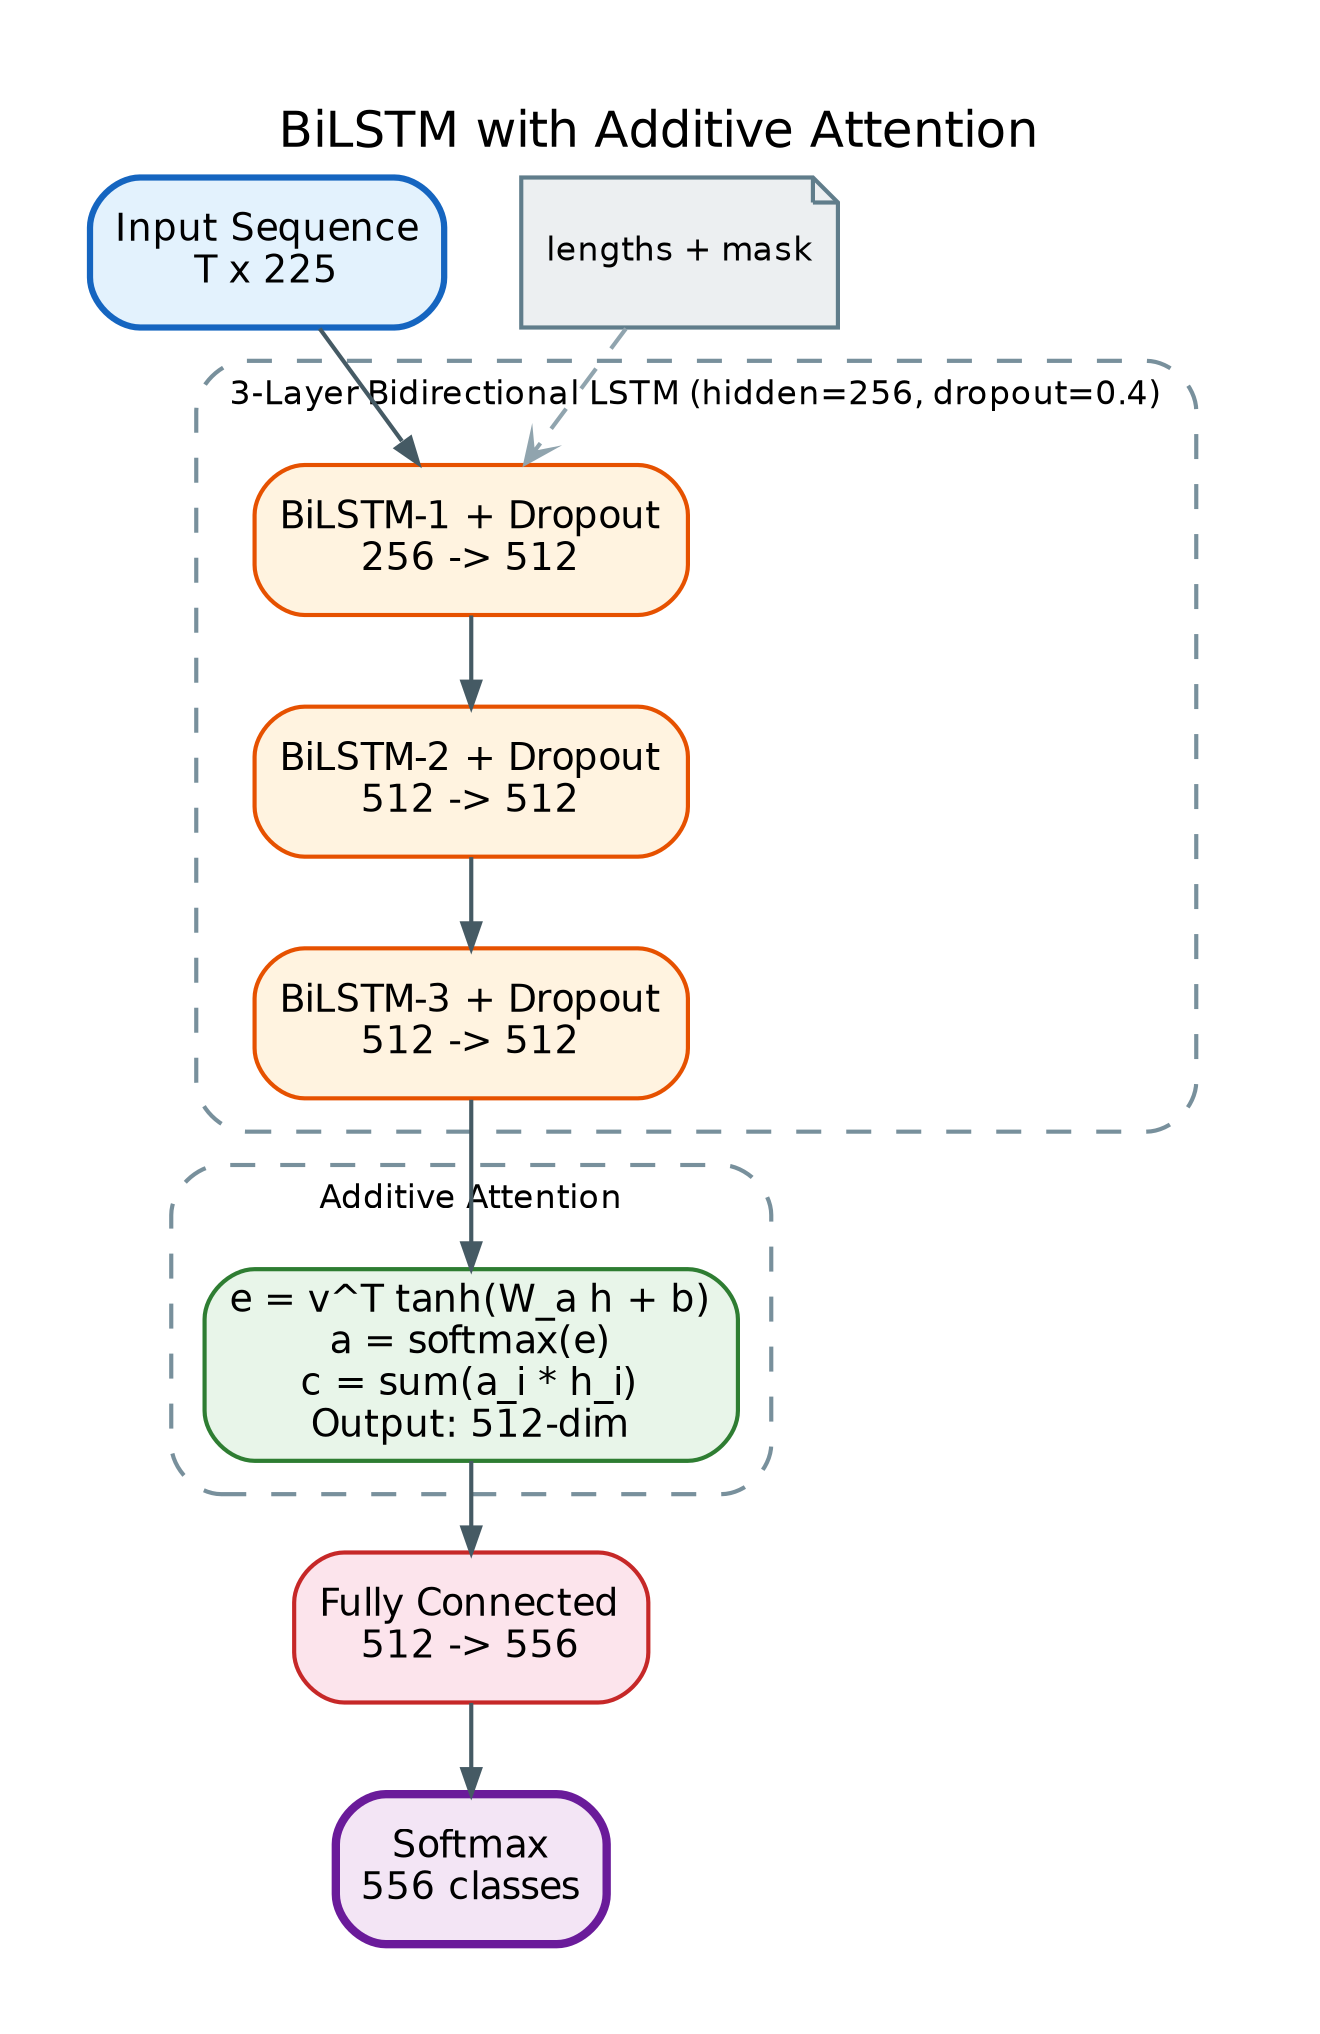

In [ ]:
from IPython.display import Image, display

# Replace this path if your file is in a different subdirectory
image_path = './fig/bilstm_arch.png'

display(Image(filename=image_path, width=400, height=200))

### Transformer Architecture

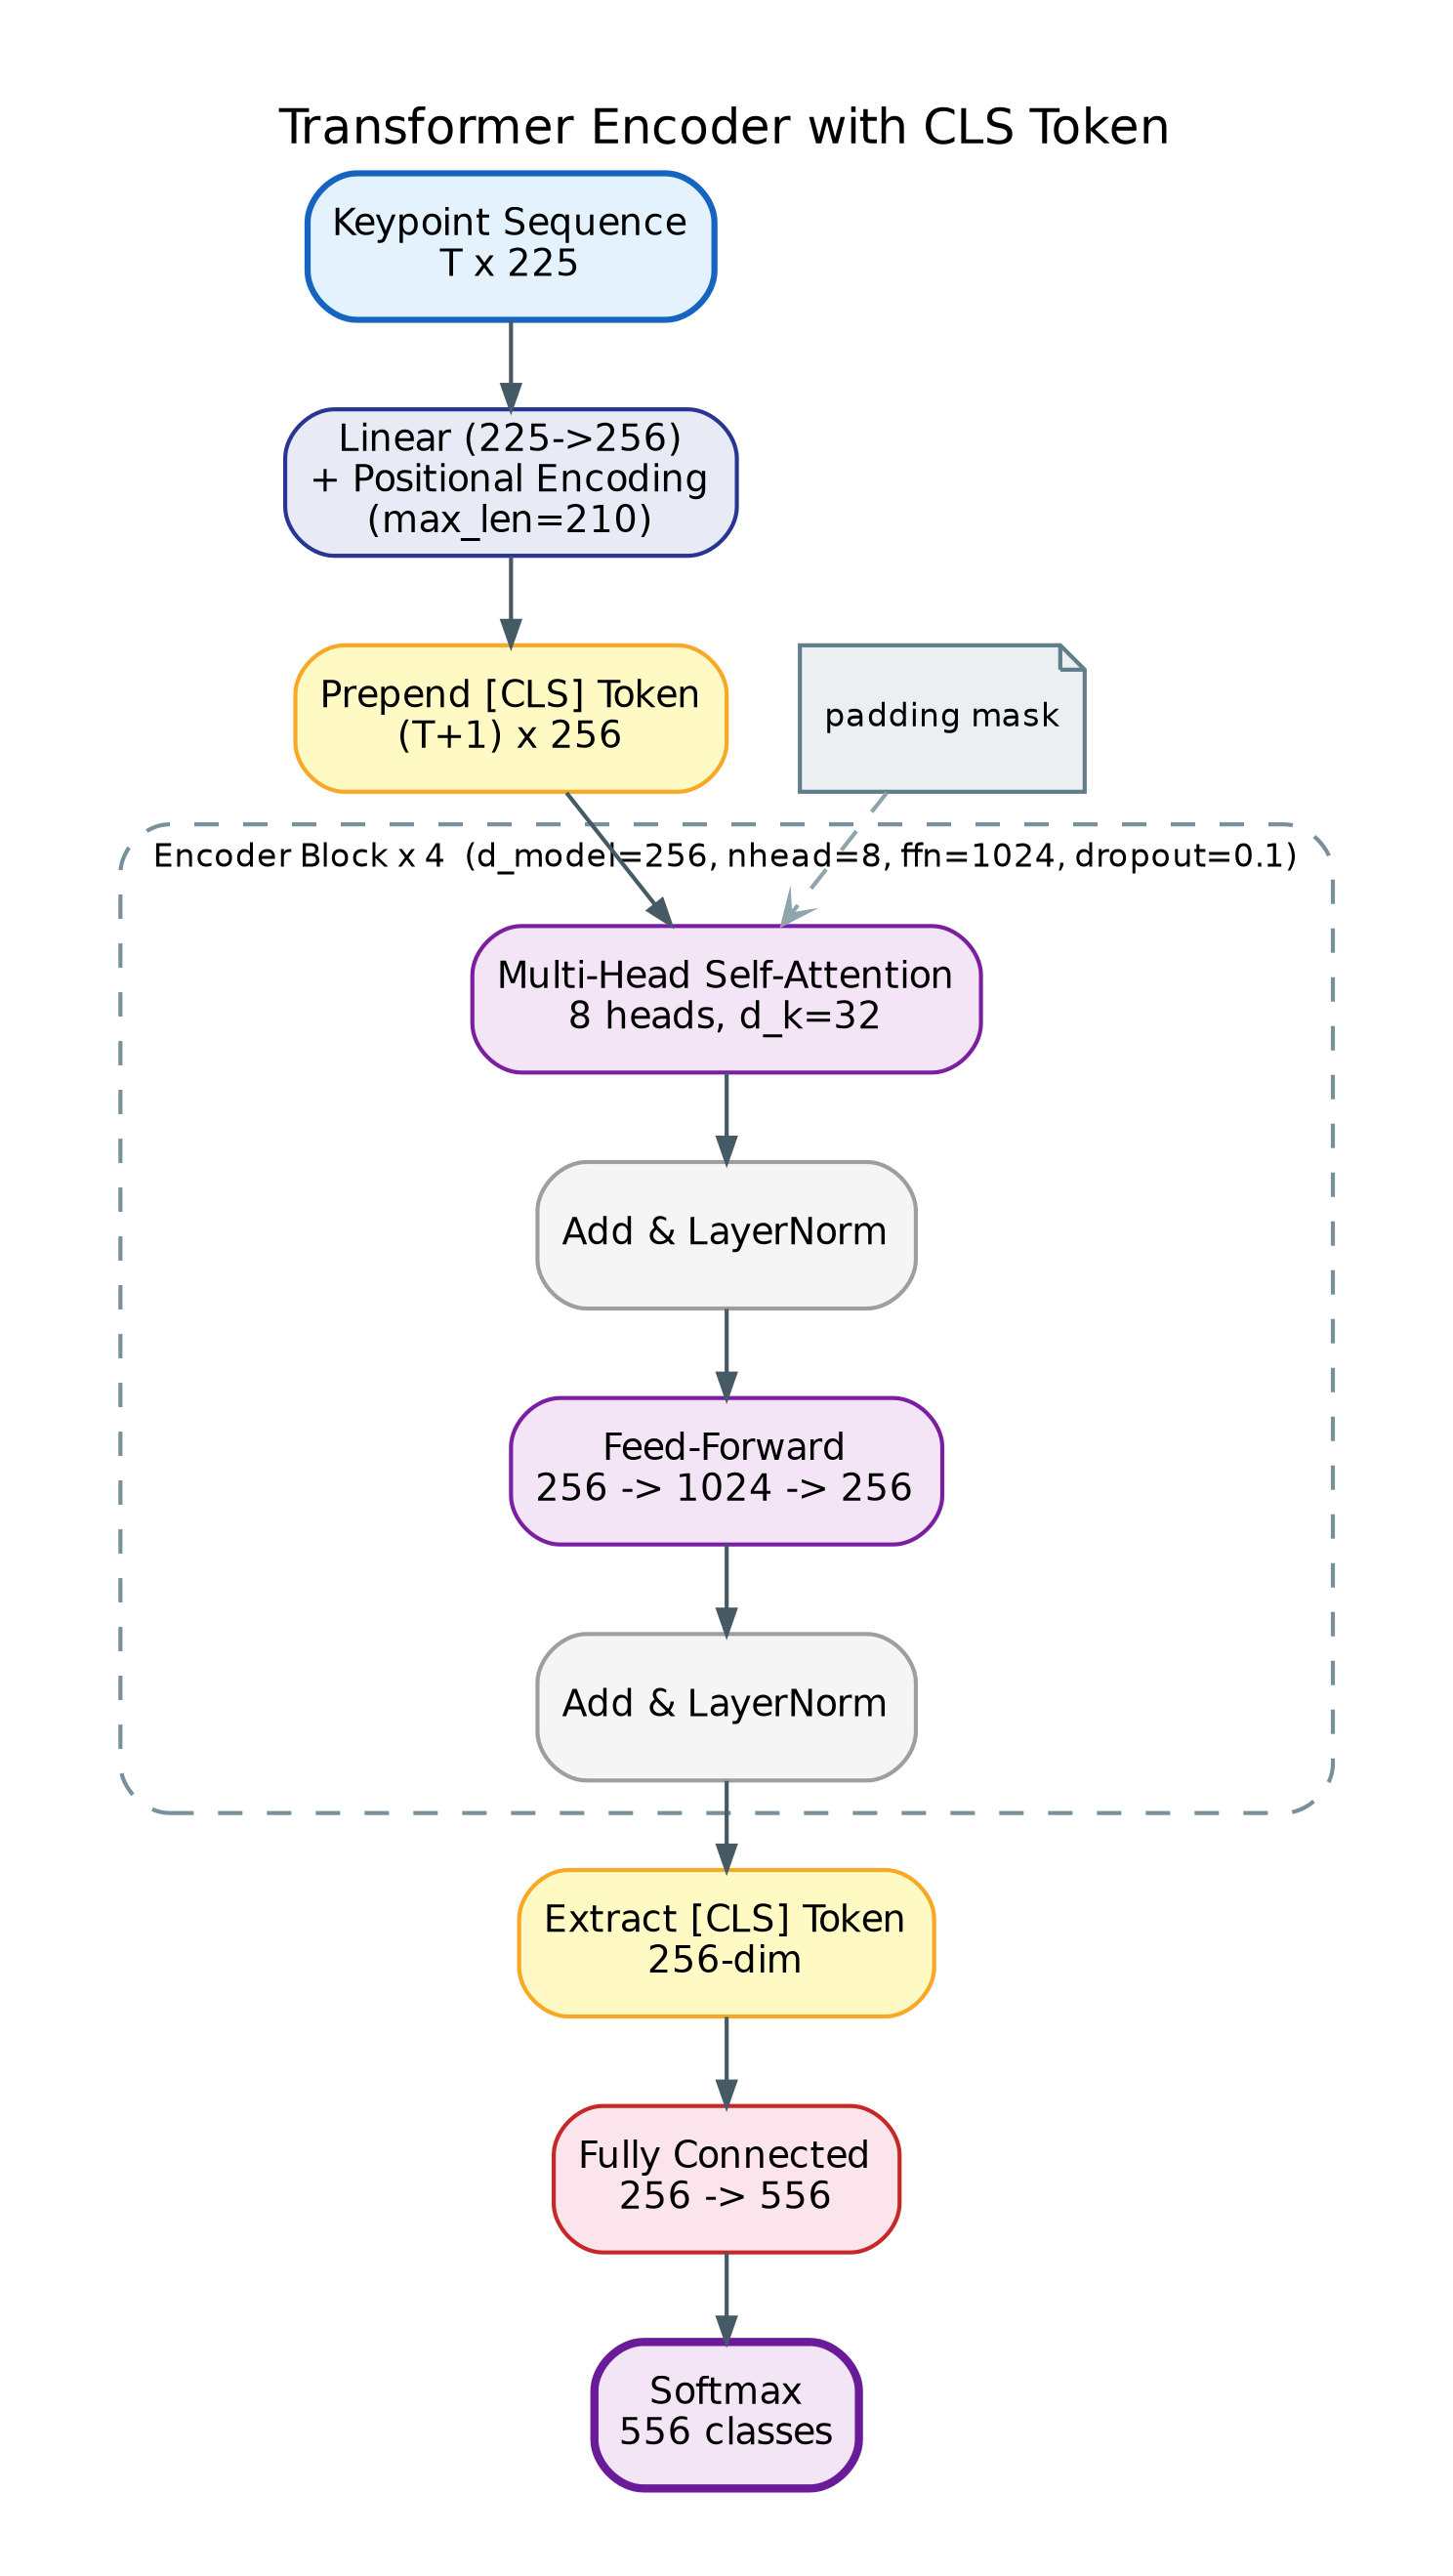

In [ ]:
from IPython.display import Image, display

# Replace this path if your file is in a different subdirectory
image_path = './fig/transformer_arch.png'

display(Image(filename=image_path, width=400, height=200))

### STGCN Architecture

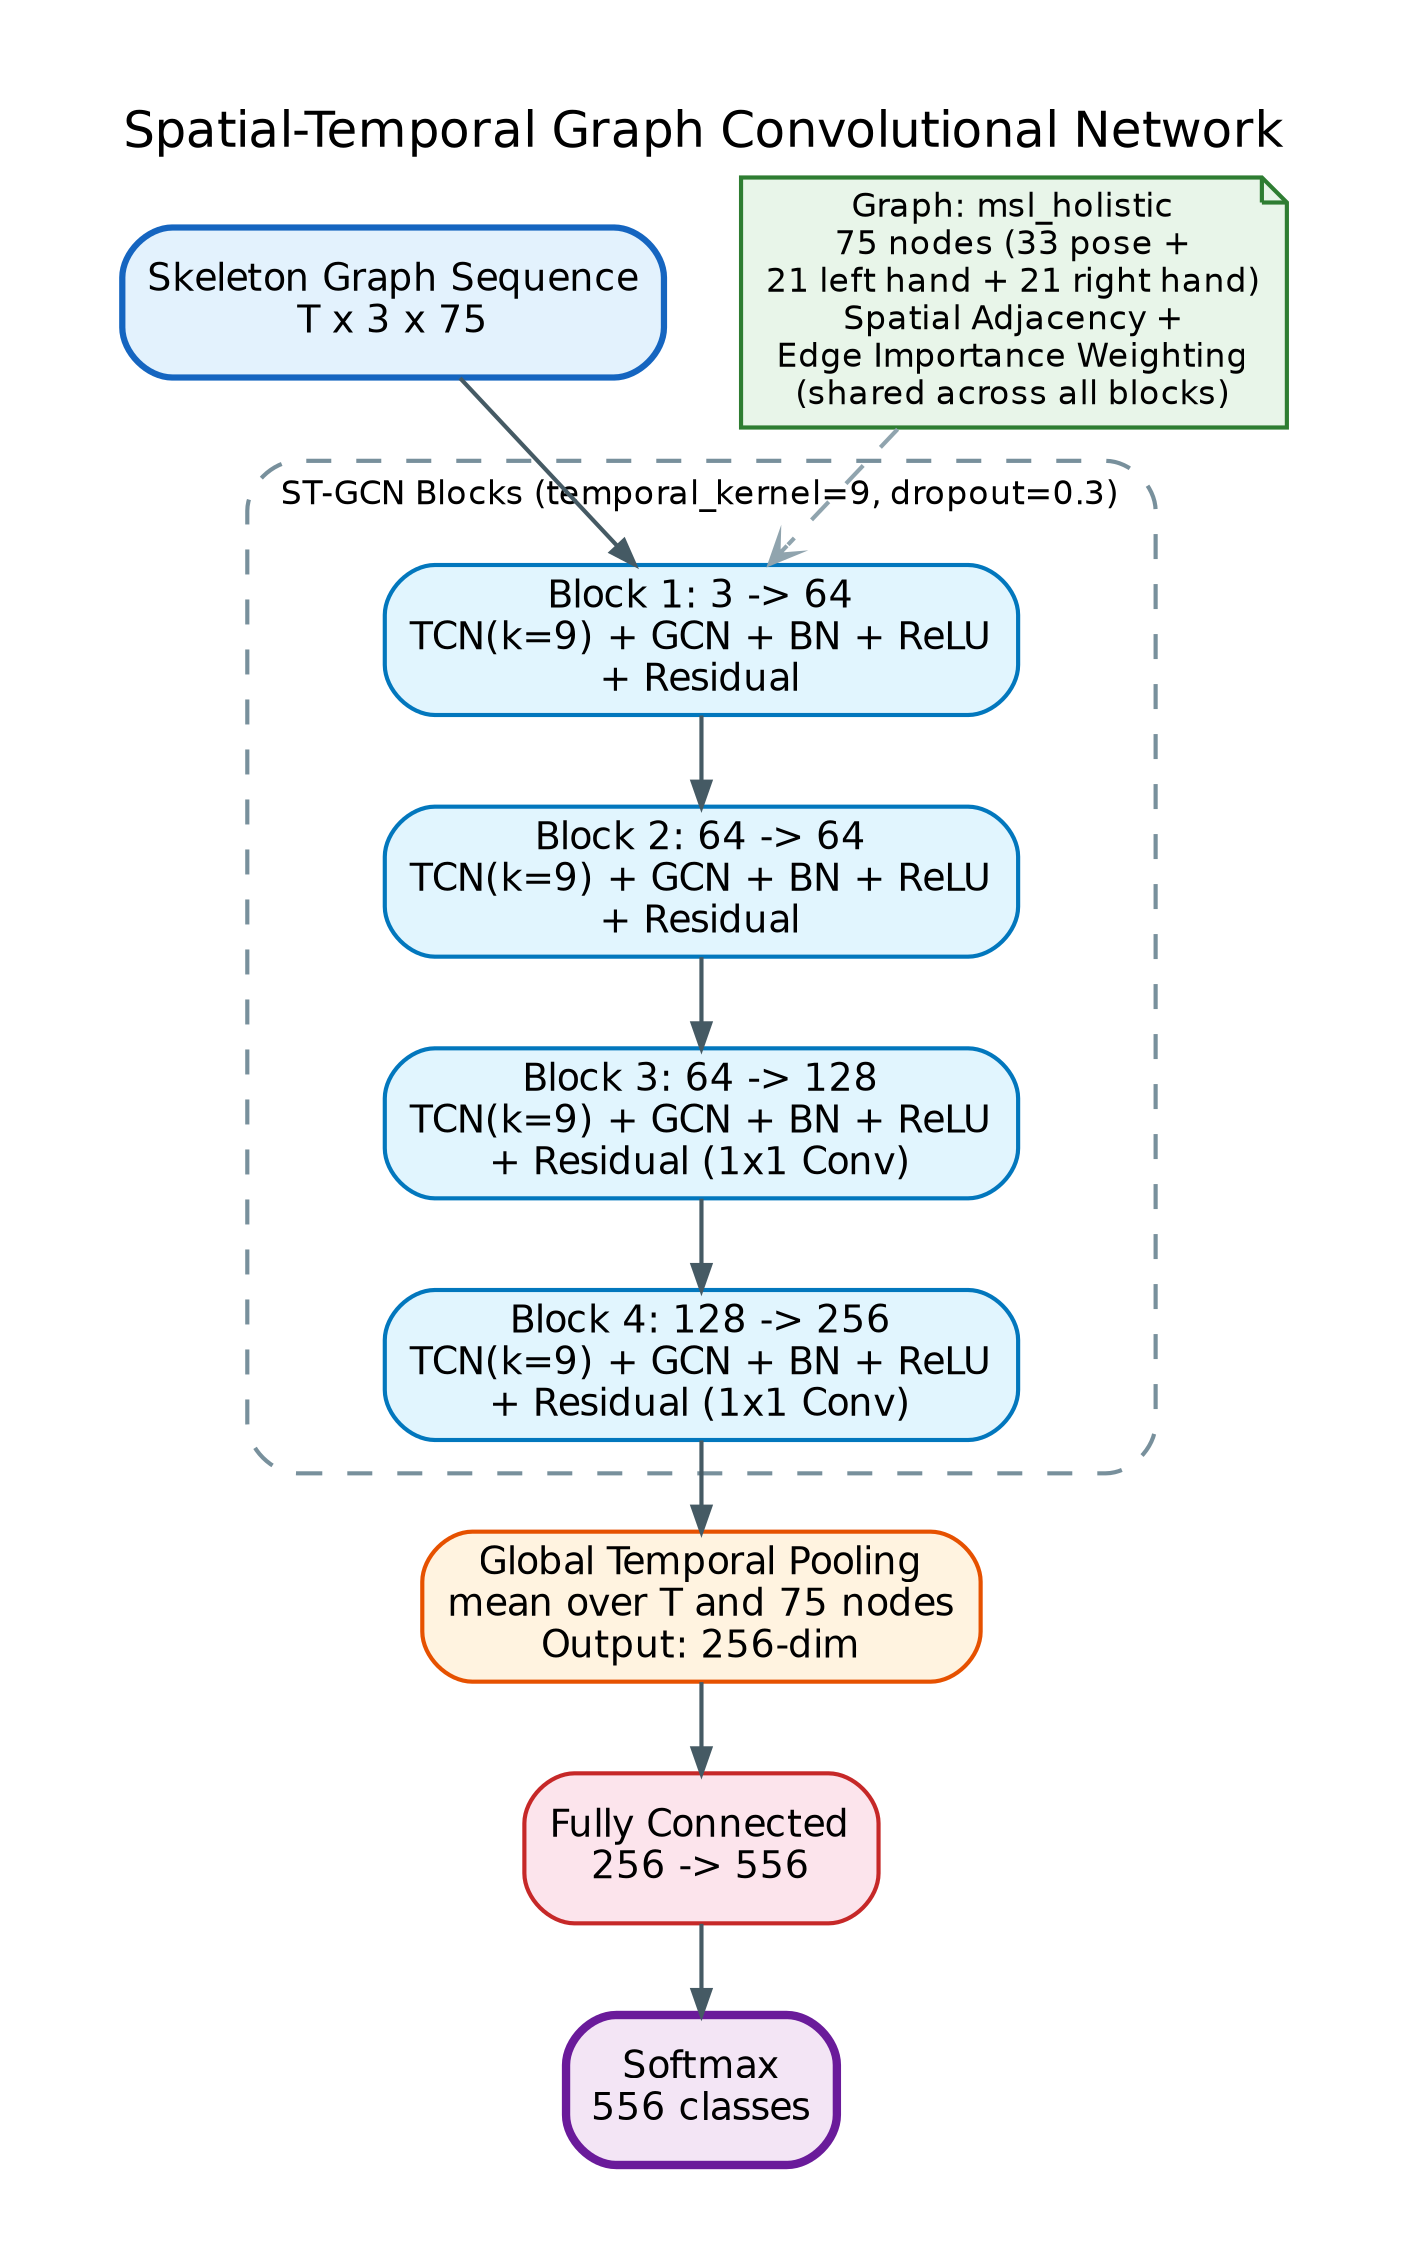

In [ ]:
from IPython.display import Image, display

# Replace this path if your file is in a different subdirectory
image_path = './fig/stgcn_arch.png'

display(Image(filename=image_path, width=400, height=200))

## Configuration File

In [ ]:
!cat config/config.yaml

# ============================================================
# Myanmar Sign Language Recognition - Configuration
# ============================================================

data:
  video_dir: "data/videos"
  keypoint_dir: "data/keypoints"
  augmented_dir: "data/augmented"
  annotation_file: "data/annotations.txt"
  label_map_file: "data/label_map.json"
  split_file: "data/splits.json"

  # MediaPipe feature dimensions
  pose_landmarks: 33          # 33 body landmarks
  hand_landmarks: 21          # 21 landmarks per hand
  num_nodes: 75               # 33 + 21 + 21
  coord_dim: 3                # x, y, z
  feature_dim: 225            # 75 * 3 (flattened per frame)

  max_seq_len: 200            # Maximum frames (videos longer are trimmed)
  min_seq_len: 5              # Minimum frames (shorter are skipped)

  # Data split
  test_ratio: 0.15
  val_ratio: 0.15
  n_folds: 5                  # For cross-validation experiments
  seed: 42

augmentation:
  enabled: true
  aug_factor: 20 

### Training BiLSTM Model

In [ ]:
!time bash scripts/04_train.sh bilstm exp_bilstm

 Training MSL Recognition Model
 Model      : bilstm
 Experiment : exp_bilstm
 Config     : config/config.yaml

 Data: train=912, val=48, test=48 (all-class design)

[GPU]
NVIDIA GeForce RTX 3060, 12288 MiB, 11008 MiB, 34

2026-06-17 19:32:57 | INFO     | train | Experiment: exp_bilstm  Model: bilstm
2026-06-17 19:32:57 | INFO     | train | Classes: 556
2026-06-17 19:32:57 | INFO     | train | Using all-class manifest: train=912, val=48, test=48

[DataLoaders]
  Train: 912 samples, 28 batches
  Val:   48   samples, 2 batches
  Test:  48  samples, 2 batches

2026-06-17 19:32:57 | INFO     | train | Model: bilstm  Params: 4,813,806
2026-06-17 19:32:59 | INFO     | train | Starting training…
2026-06-17 19:33:01 | INFO     | train | Epoch   1/150 | train loss=13.6913 top1=0.33% | val loss=12.6591 top1=0.00% top5=3.12% | lr=5.45e-05 | 2s
2026-06-17 19:33:01 | INFO     | train |   ★ New best val top-1: 0.00%
2026-06-17 19:33:03 | INFO     | train | Epoch   2/150 | train loss=12.5948 top1=2.2

### Evaluate BiLSTM Model

In [ ]:
!time bash scripts/05_evaluate.sh bilstm exp_bilstm

 Evaluation — bilstm / exp_bilstm
 Checkpoint : results/exp_bilstm/checkpoints/best.pth
 Output dir : results/exp_bilstm/evaluation

── Validation set ──────────────────────────────────────────
2026-06-17 19:37:30 | INFO     | evaluate | Loaded checkpoint: results/exp_bilstm/checkpoints/best.pth  Model: bilstm
2026-06-17 19:37:30 | INFO     | evaluate | Evaluating 48 samples from 'val' split
2026-06-17 19:37:30 | INFO     | evaluate | Model loaded. Evaluating 48 samples…
/home/elio/my_workspace/envs/aiclassenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/elio/my_workspace/envs/aiclassenv/lib/python3.10/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could

### Let's see Confusion Matrix  

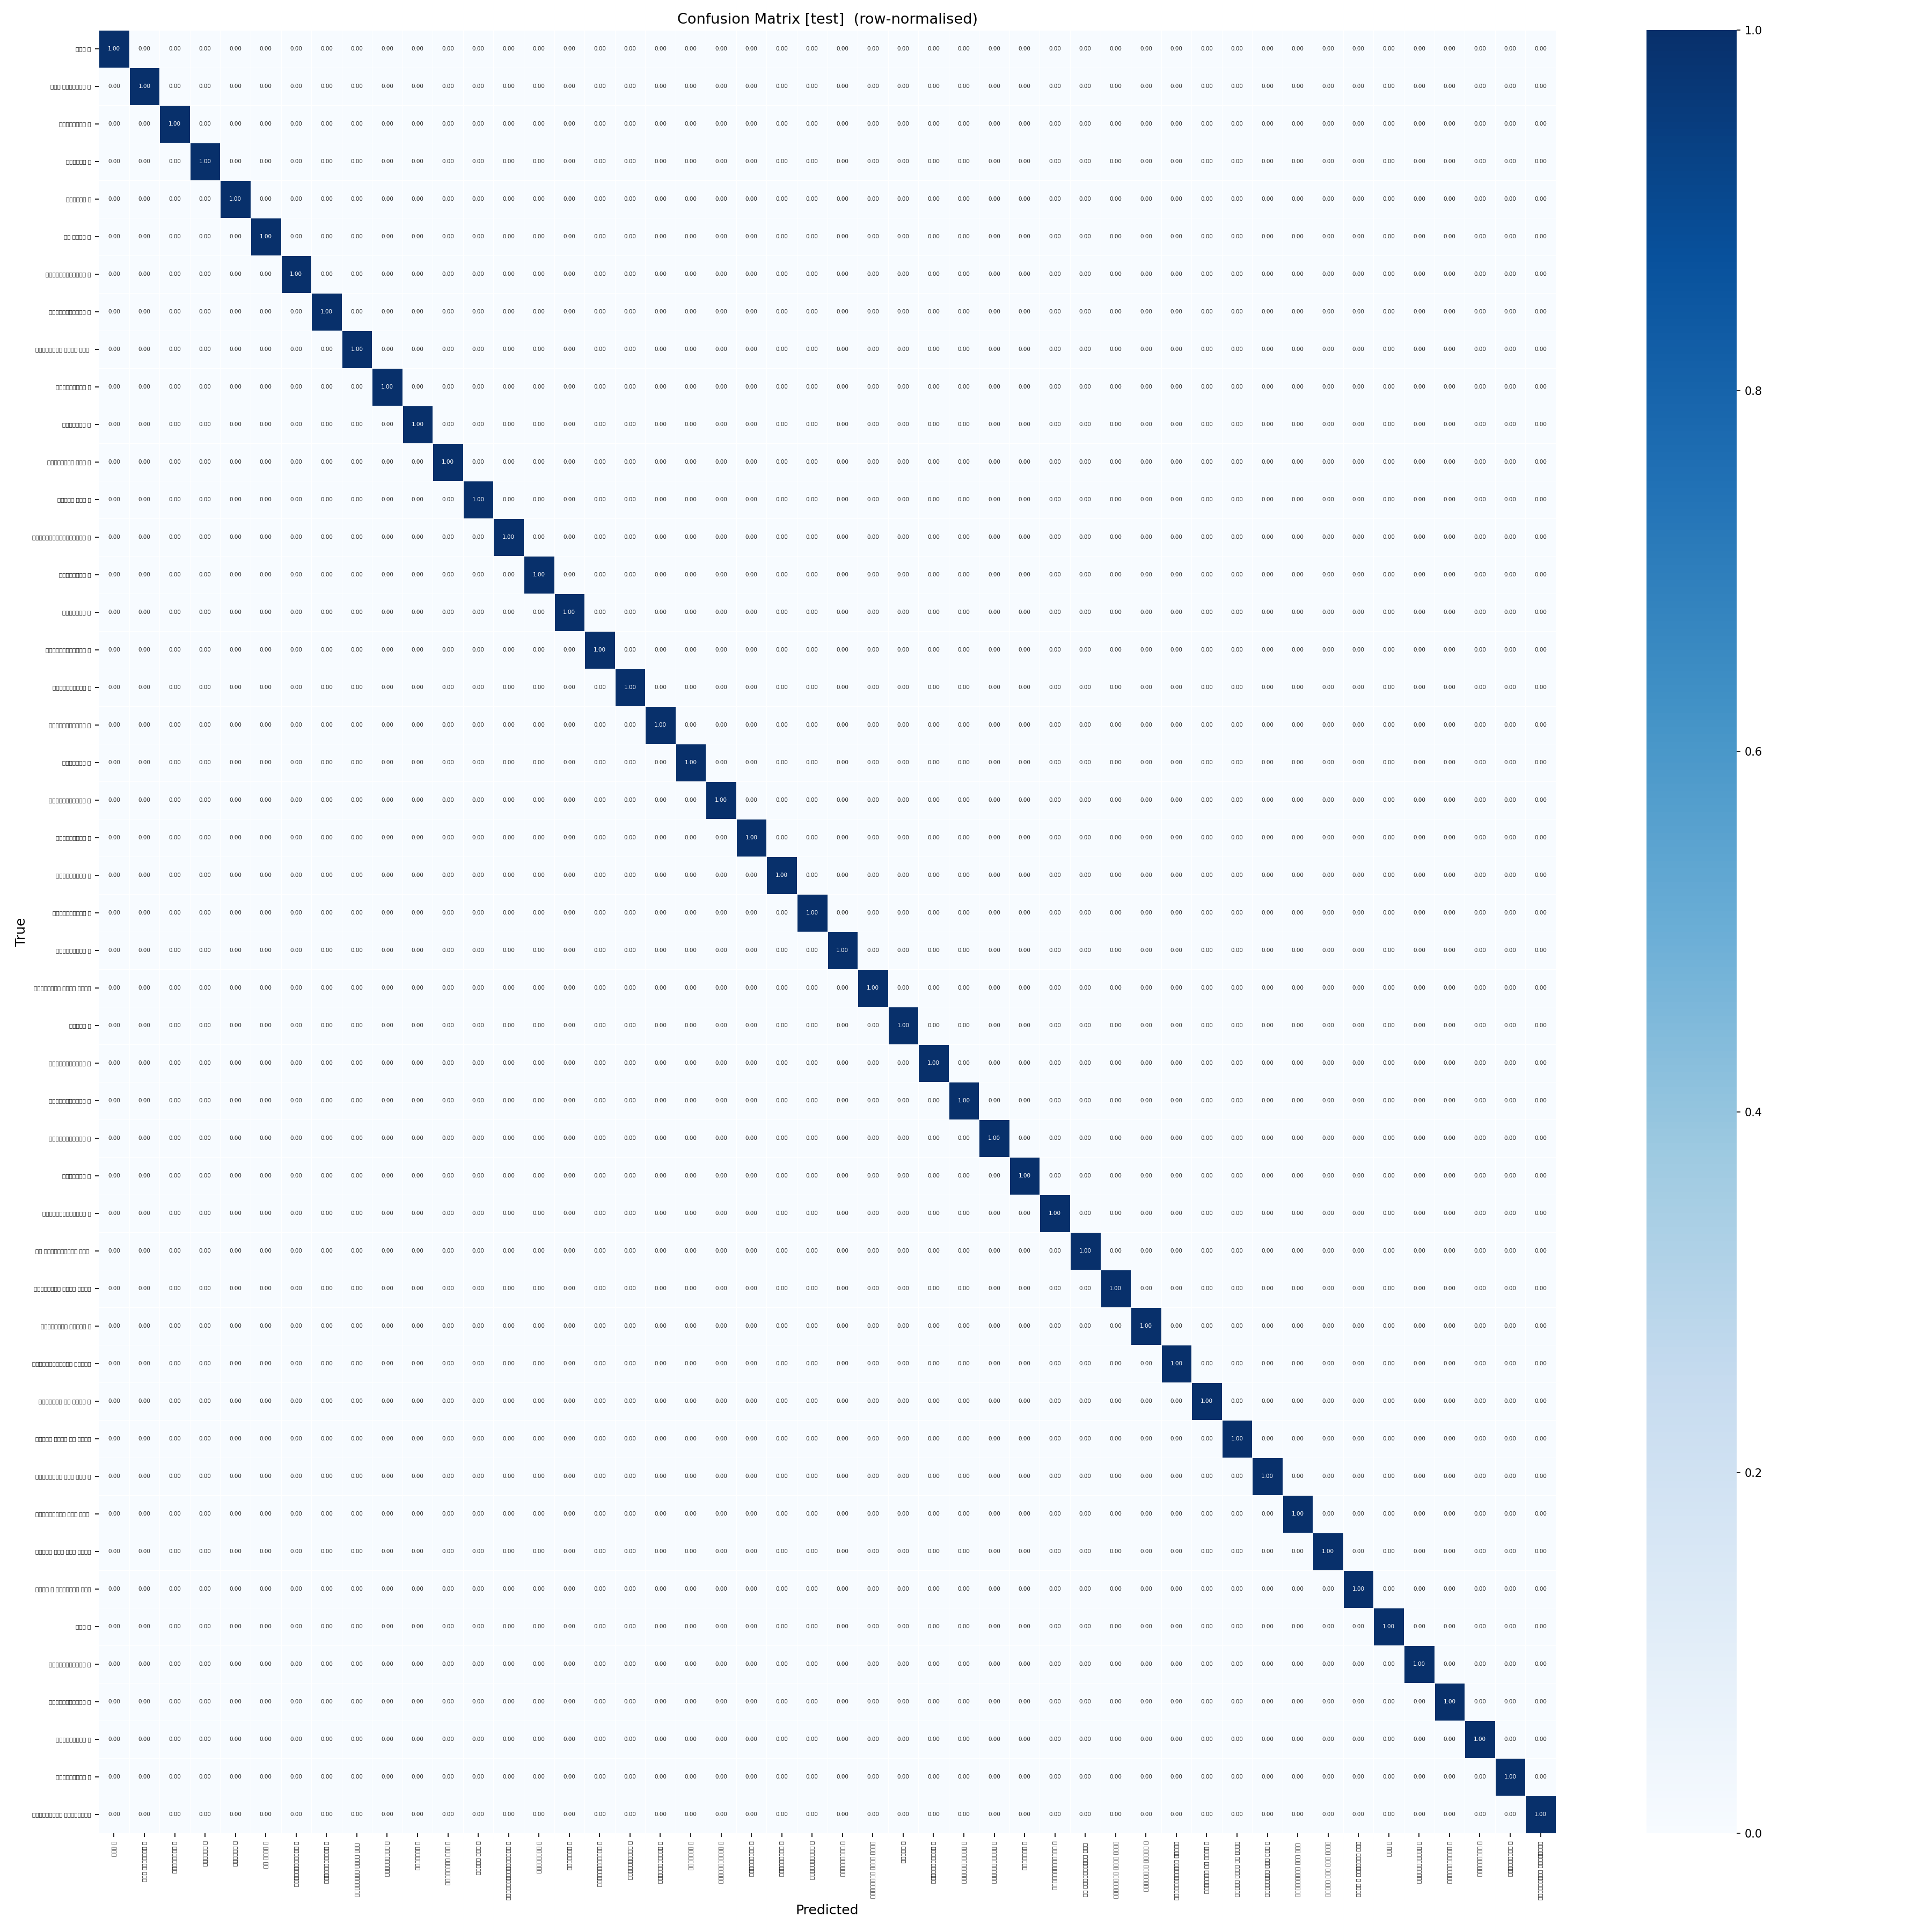

In [ ]:
from IPython.display import Image, display

# Replace this path if your file is in a different subdirectory
image_path = './results/exp_bilstm/evaluation/confusion_matrix_test.png'

display(Image(filename=image_path, width=400, height=200))

In [ ]:
!cat results/exp_bilstm/evaluation/metrics_test.json

{
  "split": "test",
  "num_samples": 48,
  "num_classes": 556,
  "top1_accuracy": 1.0,
  "top5_accuracy": 1.0,
  "precision_macro": 1.0,
  "recall_macro": 1.0,
  "f1_macro": 1.0,
  "precision_weighted": 1.0,
  "recall_weighted": 1.0,
  "f1_weighted": 1.0
}

**Classification report မှာ "support" ဆိုတာက test ဒေတာထဲမှာ ရှိတဲ့ reference အရေအတွက်ကို ဆိုလိုတာပါ။ အင်္ဂလိပ်လို ဆိုရင်တော့ "number of actual ground-truth samples" ပေါ့။**  

### How Support affects the other metrics:

Support act as the denominator for Precision, Recall, and F1.

- **If support = 1.0:** The model only had to predict that sign correctly once. If it gets it right, Precision = 1/1 = 1.0, Recall = 1/1 = 1.0.

- **If support = 2.0:** The model had to predict that sign correctly *twice*. If it gets both right, the score is 1.0. If it gets one right and one wrong, the Recall drops to 0.5 (1 correct out of 2 actual).


In [ ]:
!cat results/exp_bilstm/evaluation/per_class_test.csv

,precision,recall,f1-score,support
မီး ။,1.0,1.0,1.0,1.0
မီး ငြှိမ်း ။,1.0,1.0,1.0,1.0
မီးချိတ် ။,1.0,1.0,1.0,1.0
မီးကပ် ။,1.0,1.0,1.0,1.0
ရေပုံး ။,1.0,1.0,1.0,1.0
သဲ အိတ် ။,1.0,1.0,1.0,1.0
မီးသတ်ဆေးဘူး ။,1.0,1.0,1.0,1.0
မီးသတ်ရေကန် ။,1.0,1.0,1.0,1.0
မီးလောင် လွယ် သော ပစ္စည်း များ ။,1.0,1.0,1.0,1.0
လောင်စာဆီ ။,1.0,1.0,1.0,1.0
အမှိုက် ။,1.0,1.0,1.0,1.0
လျှပ်စစ် မီး ။,1.0,1.0,1.0,1.0
ဂက်စ် မီး ။,1.0,1.0,1.0,1.0
မီးကြွင်းမီးကျန် ။,1.0,1.0,1.0,1.0
မီးခလုပ် ။,1.0,1.0,1.0,1.0
မီးခြစ် ။,1.0,1.0,1.0,1.0
ဖယောင်းတိုင် ။,1.0,1.0,1.0,1.0
ခြင်ဆေးခွေ ။,1.0,1.0,1.0,1.0
အမွှေးတိုင် ။,1.0,1.0,1.0,1.0
မီးခိုး ။,1.0,1.0,1.0,1.0
အောက်စီဂျင် ။,1.0,1.0,1.0,1.0
ထွက်ပေါက် ။,1.0,1.0,1.0,1.0
မီးသတ်ကား ။,1.0,1.0,1.0,1.0
မီးသတ်သမား ။,1.0,1.0,1.0,1.0
မီးသတ်ဌာန ။,1.0,1.0,1.0,1.0
လျှပ်စစ် ဝါယာ ရှော့ ။,1.0,1.0,1.0,1.0
ရေဘေး ။,1.0,1.0,1.0,1.0
ဘေးအန္တရာယ် ။,1.0,1.0,1.0,1.0
မြစ်ခေျာင်း ။,1.0,1.0,1.0,1.0
မြေနိမ့်ဒေသ ။,1.0,1.0,1.0,1.0
ချိုင့် ။,1.0,1.0,1.0,1.0
ရေနုတ်မြောင်း ။,1.0,1.0,1.0,1.0
ရေ လွှမ်းမိုး မှု ။,1.0,1.0,1.

In [ ]:
!wc ./results/exp_bilstm/evaluation/*.csv

   52   139  2833 ./results/exp_bilstm/evaluation/per_class_test.csv
   52   139  2934 ./results/exp_bilstm/evaluation/per_class_val.csv
   49   295  8600 ./results/exp_bilstm/evaluation/predictions_test.csv
   49   300  8634 ./results/exp_bilstm/evaluation/predictions_val.csv
  202   873 23001 total


### Training Transformer Model

In [ ]:
!time bash scripts/04_train.sh transformer exp_transformer

 Training MSL Recognition Model
 Model      : transformer
 Experiment : exp_transformer
 Config     : config/config.yaml

 Data: train=912, val=48, test=48 (all-class design)

[GPU]
NVIDIA GeForce RTX 3060, 12288 MiB, 11049 MiB, 34

2026-06-17 19:38:38 | INFO     | train | Experiment: exp_transformer  Model: transformer
2026-06-17 19:38:38 | INFO     | train | Classes: 556
2026-06-17 19:38:38 | INFO     | train | Using all-class manifest: train=912, val=48, test=48

[DataLoaders]
  Train: 912 samples, 28 batches
  Val:   48   samples, 2 batches
  Test:  48  samples, 2 batches

2026-06-17 19:38:38 | INFO     | train | Model: transformer  Params: 3,362,030
2026-06-17 19:38:39 | INFO     | train | Starting training…
2026-06-17 19:38:40 | INFO     | train | Epoch   1/150 | train loss=12.5507 top1=0.33% | val loss=12.4929 top1=0.00% top5=0.00% | lr=5.45e-05 | 1s
2026-06-17 19:38:40 | INFO     | train |   ★ New best val top-1: 0.00%
2026-06-17 19:38:41 | INFO     | train | Epoch   2/150 | tr

### Evaluate Transformer Model

In [ ]:
!time bash scripts/05_evaluate.sh transformer exp_transformer

 Evaluation — transformer / exp_transformer
 Checkpoint : results/exp_transformer/checkpoints/best.pth
 Output dir : results/exp_transformer/evaluation

── Validation set ──────────────────────────────────────────
2026-06-17 19:40:10 | INFO     | evaluate | Loaded checkpoint: results/exp_transformer/checkpoints/best.pth  Model: transformer
2026-06-17 19:40:10 | INFO     | evaluate | Evaluating 48 samples from 'val' split
2026-06-17 19:40:11 | INFO     | evaluate | Model loaded. Evaluating 48 samples…
/home/elio/my_workspace/envs/aiclassenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/elio/my_workspace/envs/aiclassenv/lib/python3.10/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of th

In [ ]:
!ls ./results/exp_transformer/evaluation/*

./results/exp_transformer/evaluation/confusion_matrix_test.npy
./results/exp_transformer/evaluation/confusion_matrix_test.png
./results/exp_transformer/evaluation/confusion_matrix_val.npy
./results/exp_transformer/evaluation/confusion_matrix_val.png
./results/exp_transformer/evaluation/eval_test.log
./results/exp_transformer/evaluation/eval_val.log
./results/exp_transformer/evaluation/metrics_test.json
./results/exp_transformer/evaluation/metrics_val.json
./results/exp_transformer/evaluation/per_class_test.csv
./results/exp_transformer/evaluation/per_class_val.csv
./results/exp_transformer/evaluation/predictions_test.csv
./results/exp_transformer/evaluation/predictions_val.csv


In [ ]:
!cat ./results/exp_transformer/evaluation/predictions_val.csv | head -n 30 

sample_idx,true_label,pred_label,correct,true_idx,pred_idx,confidence,video_path,msl_gloss
0,မီး ။,မီး ။,True,0,0,0.51806640625,data/videos/idx20-1.mp4,မီး
1,မီး ငြှိမ်း ။,မီး ငြှိမ်း ။,True,1,1,0.457763671875,data/videos/idx20-2.mp4,မီး ငြှိမ်း
2,မီးချိတ် ။,မီးချိတ် ။,True,2,2,0.54248046875,data/videos/idx20-3.mp4,မီးချိတ်
3,မီးကပ် ။,မီးကပ် ။,True,3,3,0.1412353515625,data/videos/idx20-4.mp4,မီးကပ်
4,ရေပုံး ။,ရေပုံး ။,True,4,4,0.56884765625,data/videos/idx20-5.mp4,ရေပုံး
5,သဲ အိတ် ။,သဲ အိတ် ။,True,5,5,0.60009765625,data/videos/idx20-6.mp4,အိတ် ထဲ သဲ
6,မီးသတ်ဆေးဘူး ။,မီးသတ်ဆေးဘူး ။,True,6,6,0.2332763671875,data/videos/idx20-7.mp4,အနီ ဘူး ဖြန်း
7,မီးသတ်ရေကန် ။,မီးသတ်ရေကန် ။,True,7,7,0.402587890625,data/videos/idx20-8.mp4,ကန် ထဲ ရေ သိမ်း
8,မီးလောင် လွယ် သော ပစ္စည်း များ ။,မီးလောင် လွယ် သော ပစ္စည်း များ ။,True,8,8,0.251220703125,data/videos/idx20-9.mp4,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး
9,လောင်စာဆီ ။,လောင်စာဆီ ။,True,9,9,0.3447265625,data/videos/idx20-10.mp4,ဓာတ်ဆီ 9 2 9 

In [ ]:
!cat ./results/exp_transformer/evaluation/predictions_val.csv | tail -n 30 

18,အမွှေးတိုင် ။,အမွှေးတိုင် ။,True,18,18,0.495361328125,data/videos/idx20-19.mp4,အမွှေးတိုင်
19,မီးခိုး ။,မီးခိုး ။,True,19,19,0.51904296875,data/videos/idx20-20.mp4,မီး အခိုးအငွေ့ အမဲ
20,အောက်စီဂျင် ။,အောက်စီဂျင် ။,True,20,20,0.456787109375,data/videos/idx20-21.mp4,အောက်ဆီဂျင် o 2
21,ထွက်ပေါက် ။,ထွက်ပေါက် ။,True,21,21,0.48291015625,data/videos/idx20-22.mp4,ဆိုင်းဘုတ် အဲဒီက ပြေး တံခါးပေါက်
22,မီးသတ်ကား ။,မီးသတ်ကား ။,True,22,22,0.1357421875,data/videos/idx20-23.mp4,ကား အရေးပေါ် မီးသတ်
23,မီးသတ်သမား ။,မီးသတ်သမား ။,True,23,23,0.732421875,data/videos/idx20-24.mp4,မီးသတ်သမား
24,မီးသတ်ဌာန ။,မီးသတ်ဌာန ။,True,24,24,0.354736328125,data/videos/idx20-25.mp4,မီးသတ် အိမ် ထဲ
25,လျှပ်စစ် ဝါယာ ရှော့ ။,လျှပ်စစ် ဝါယာ ရှော့ ။,True,25,25,0.378662109375,data/videos/idx20-26.mp4,လျှပ်စစ် ကြိုး ရှော့
26,ရေဘေး ။,ရေဘေး ။,True,26,26,0.425048828125,data/videos/idx20-27.mp4,ရေ ကြီး
27,ဘေးအန္တရာယ် ။,ဘေးအန္တရာယ် ။,True,27,27,0.42236328125,data/videos/idx20-28.mp4,သဘာဝ ဒုက္ခ
28,မြစ်ခေျာင်း ။,မြစ်ခေျာင်း ။,True,28,2

In [ ]:
!wc ./results/exp_transformer/evaluation/*.csv

   52   139  2833 ./results/exp_transformer/evaluation/per_class_test.csv
   52   139  2976 ./results/exp_transformer/evaluation/per_class_val.csv
   49   295  8576 ./results/exp_transformer/evaluation/predictions_test.csv
   49   296  8599 ./results/exp_transformer/evaluation/predictions_val.csv
  202   869 22984 total


### Training STGCN Model

In [ ]:
!time bash scripts/04_train.sh stgcn exp_stgcn

 Training MSL Recognition Model
 Model      : stgcn
 Experiment : exp_stgcn
 Config     : config/config.yaml

 Data: train=912, val=48, test=48 (all-class design)

[GPU]
NVIDIA GeForce RTX 3060, 12288 MiB, 11048 MiB, 38

2026-06-17 19:40:47 | INFO     | train | Experiment: exp_stgcn  Model: stgcn
2026-06-17 19:40:47 | INFO     | train | Classes: 556
2026-06-17 19:40:47 | INFO     | train | Using all-class manifest: train=912, val=48, test=48

[DataLoaders]
  Train: 912 samples, 28 batches
  Val:   48   samples, 2 batches
  Test:  48  samples, 2 batches

2026-06-17 19:40:48 | INFO     | train | Model: stgcn  Params: 2,780,143
2026-06-17 19:40:49 | INFO     | train | Starting training…
2026-06-17 19:40:58 | INFO     | train | Epoch   1/150 | train loss=13.9582 top1=0.67% | val loss=12.7599 top1=3.12% top5=3.12% | lr=5.45e-05 | 10s
2026-06-17 19:40:59 | INFO     | train |   ★ New best val top-1: 3.12%
2026-06-17 19:41:07 | INFO     | train | Epoch   2/150 | train loss=13.1050 top1=1.00% |

### Evaluate STGCN Model

In [ ]:
!time bash scripts/05_evaluate.sh stgcn exp_stgcn

 Evaluation — stgcn / exp_stgcn
 Checkpoint : results/exp_stgcn/checkpoints/best.pth
 Output dir : results/exp_stgcn/evaluation

── Validation set ──────────────────────────────────────────
2026-06-17 19:49:48 | INFO     | evaluate | Loaded checkpoint: results/exp_stgcn/checkpoints/best.pth  Model: stgcn
2026-06-17 19:49:48 | INFO     | evaluate | Evaluating 48 samples from 'val' split
2026-06-17 19:49:48 | INFO     | evaluate | Model loaded. Evaluating 48 samples…
/home/elio/my_workspace/envs/aiclassenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
/home/elio/my_workspace/envs/aiclassenv/lib/python3.10/site-packages/sklearn/utils/multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could repre

In [ ]:
!ls ./results/exp_stgcn/evaluation/

confusion_matrix_test.npy  eval_test.log      per_class_test.csv
confusion_matrix_test.png  eval_val.log       per_class_val.csv
confusion_matrix_val.npy   metrics_test.json  predictions_test.csv
confusion_matrix_val.png   metrics_val.json   predictions_val.csv


In [ ]:
!cat ./results/exp_stgcn/evaluation/predictions_val.csv| head -n 50

sample_idx,true_label,pred_label,correct,true_idx,pred_idx,confidence,video_path,msl_gloss
0,မီး ။,မီး ။,True,0,0,0.6572265625,data/videos/idx20-1.mp4,မီး
1,မီး ငြှိမ်း ။,မီး ငြှိမ်း ။,True,1,1,0.56396484375,data/videos/idx20-2.mp4,မီး ငြှိမ်း
2,မီးချိတ် ။,မီးချိတ် ။,True,2,2,0.2159423828125,data/videos/idx20-3.mp4,မီးချိတ်
3,မီးကပ် ။,မီးကပ် ။,True,3,3,0.310302734375,data/videos/idx20-4.mp4,မီးကပ်
4,ရေပုံး ။,ရေပုံး ။,True,4,4,0.6904296875,data/videos/idx20-5.mp4,ရေပုံး
5,သဲ အိတ် ။,သဲ အိတ် ။,True,5,5,0.76904296875,data/videos/idx20-6.mp4,အိတ် ထဲ သဲ
6,မီးသတ်ဆေးဘူး ။,မီးသတ်ဆေးဘူး ။,True,6,6,0.165283203125,data/videos/idx20-7.mp4,အနီ ဘူး ဖြန်း
7,မီးသတ်ရေကန် ။,မီးသတ်ရေကန် ။,True,7,7,0.294921875,data/videos/idx20-8.mp4,ကန် ထဲ ရေ သိမ်း
8,မီးလောင် လွယ် သော ပစ္စည်း များ ။,မီးလောင် လွယ် သော ပစ္စည်း များ ။,True,8,8,0.028350830078125,data/videos/idx20-9.mp4,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး
9,လောင်စာဆီ ။,လောင်စာဆီ ။,True,9,9,0.2491455078125,data/videos/idx20-10.mp4,ဓာတ်ဆီ 9 2 9 

In [ ]:
!cat ./results/exp_stgcn/evaluation/predictions_test.csv| head -n 50

sample_idx,true_label,pred_label,correct,true_idx,pred_idx,confidence,video_path,msl_gloss
0,မီး ။,မီး ။,True,0,0,0.74658203125,data/videos/idx20-1.mp4,မီး
1,မီး ငြှိမ်း ။,မီး ငြှိမ်း ။,True,1,1,0.65185546875,data/videos/idx20-2.mp4,မီး ငြှိမ်း
2,မီးချိတ် ။,မီးချိတ် ။,True,2,2,0.9248046875,data/videos/idx20-3.mp4,မီးချိတ်
3,မီးကပ် ။,မီးကပ် ။,True,3,3,0.8076171875,data/videos/idx20-4.mp4,မီးကပ်
4,ရေပုံး ။,ရေပုံး ။,True,4,4,0.69384765625,data/videos/idx20-5.mp4,ရေပုံး
5,သဲ အိတ် ။,သဲ အိတ် ။,True,5,5,0.81787109375,data/videos/idx20-6.mp4,အိတ် ထဲ သဲ
6,မီးသတ်ဆေးဘူး ။,မီးသတ်ဆေးဘူး ။,True,6,6,0.272216796875,data/videos/idx20-7.mp4,အနီ ဘူး ဖြန်း
7,မီးသတ်ရေကန် ။,မီးသတ်ရေကန် ။,True,7,7,0.85888671875,data/videos/idx20-8.mp4,ကန် ထဲ ရေ သိမ်း
8,မီးလောင် လွယ် သော ပစ္စည်း များ ။,မီးလောင် လွယ် သော ပစ္စည်း များ ။,True,8,8,0.31298828125,data/videos/idx20-9.mp4,မီးလောင် တစ်ခါတည်း ဓာတ်ဆီ စက္ကူ စွန့်ပစ် အမျိုးမျိုး
9,လောင်စာဆီ ။,လောင်စာဆီ ။,True,9,9,0.44873046875,data/videos/idx20-10.mp4,ဓာတ်ဆီ 9 2 9 5 အောက်

## Experimental Results

မော်ဒယ် သုံးမျိုးရဲ့ learning rate နဲ့ validation/testing ရလဒ်တွေကို အသေးစိတ် လေ့လာကြည့်ကြရအောင်။  

In [ ]:
#!python src/plot_results.py \
#    --exp results/exp_bilstm results/exp_transformer results/exp_stgcn \
#    --output results/model_comparison.png

Training curves saved → results/exp_bilstm/training_curves.png
Training curves saved → results/exp_transformer/training_curves.png
Training curves saved → results/exp_stgcn/training_curves.png
Comparison chart saved → results/model_comparison.png


In [ ]:
!python src/plot_results_v2.py \
      --exp results/exp_bilstm results/exp_transformer results/exp_stgcn \
      --output results/comparison_val.png \
      --output_test results/comparison_test.png

Training curves saved → results/exp_bilstm/training_curves.png
Training curves saved → results/exp_transformer/training_curves.png
Training curves saved → results/exp_stgcn/training_curves.png
Val comparison chart saved → results/comparison_val.png
Test comparison chart saved → results/comparison_test.png


### Training Curves of BiLSTM

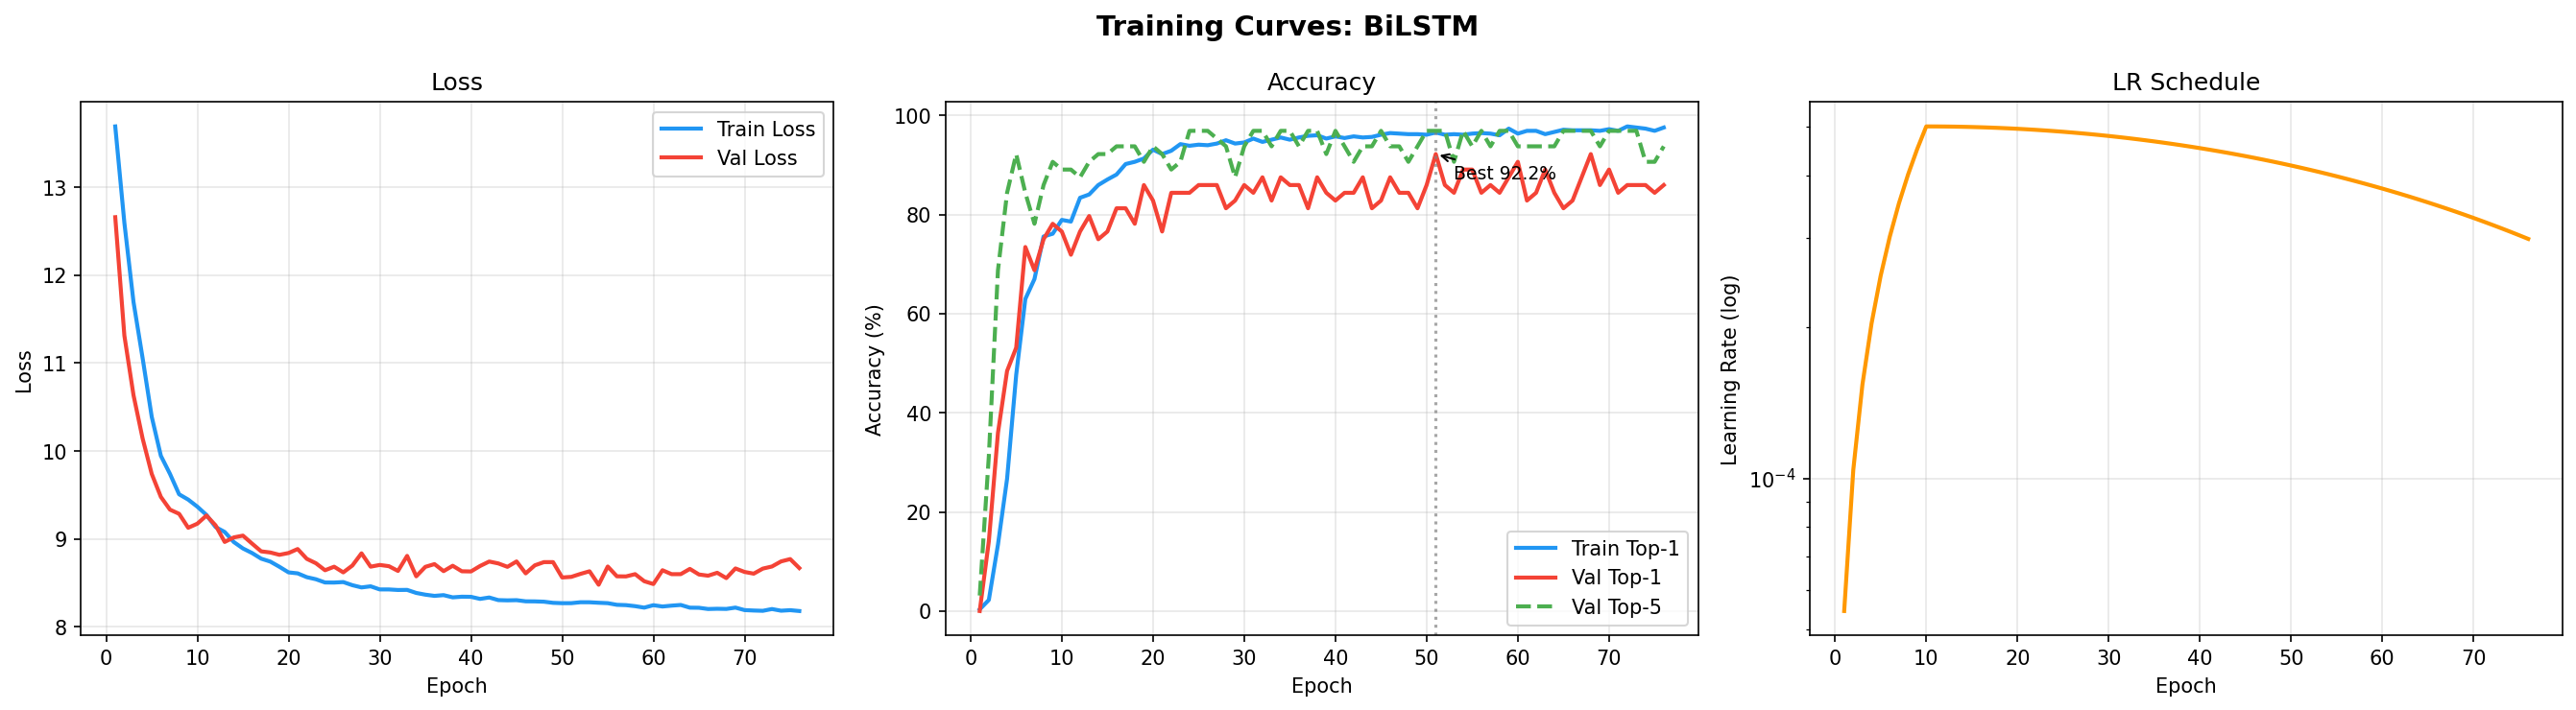

In [ ]:
from IPython.display import Image, display

image_path = './results/exp_bilstm/training_curves.png'
display(Image(filename=image_path))

### Training Curve of Transformer

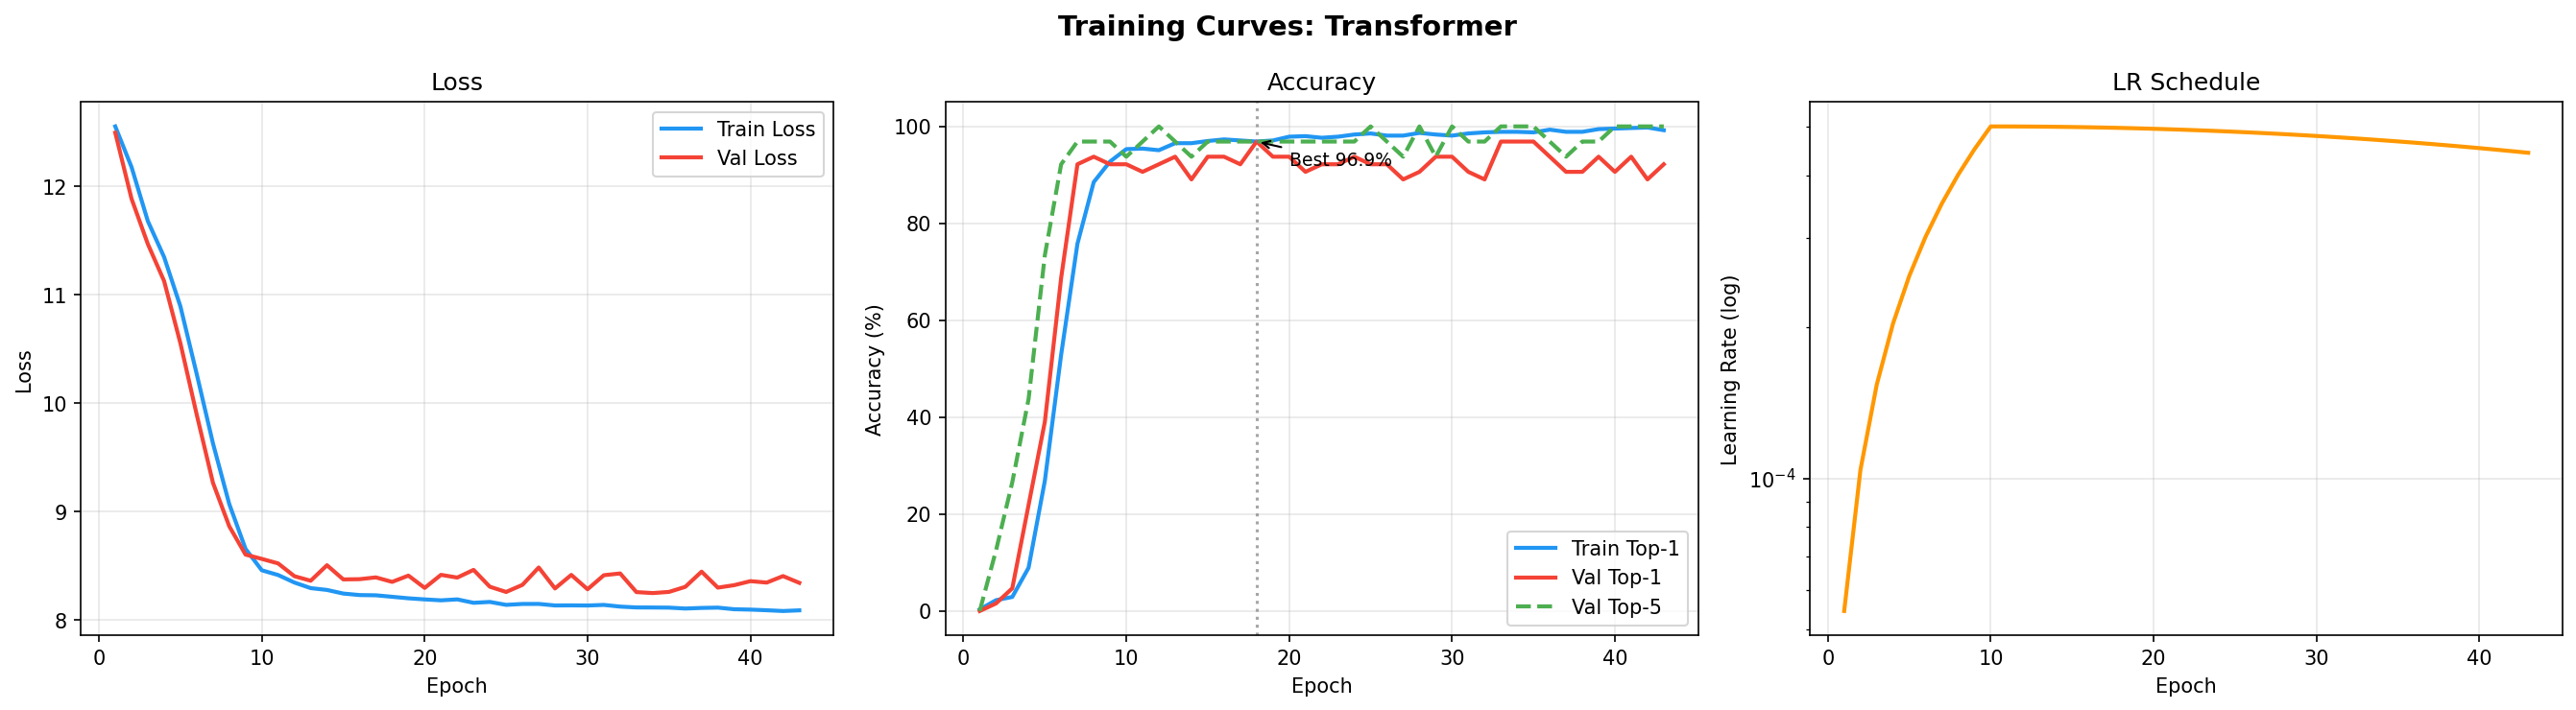

In [ ]:
from IPython.display import Image, display

image_path = './results/exp_transformer/training_curves.png'
display(Image(filename=image_path))

### Training Curve of STGCN

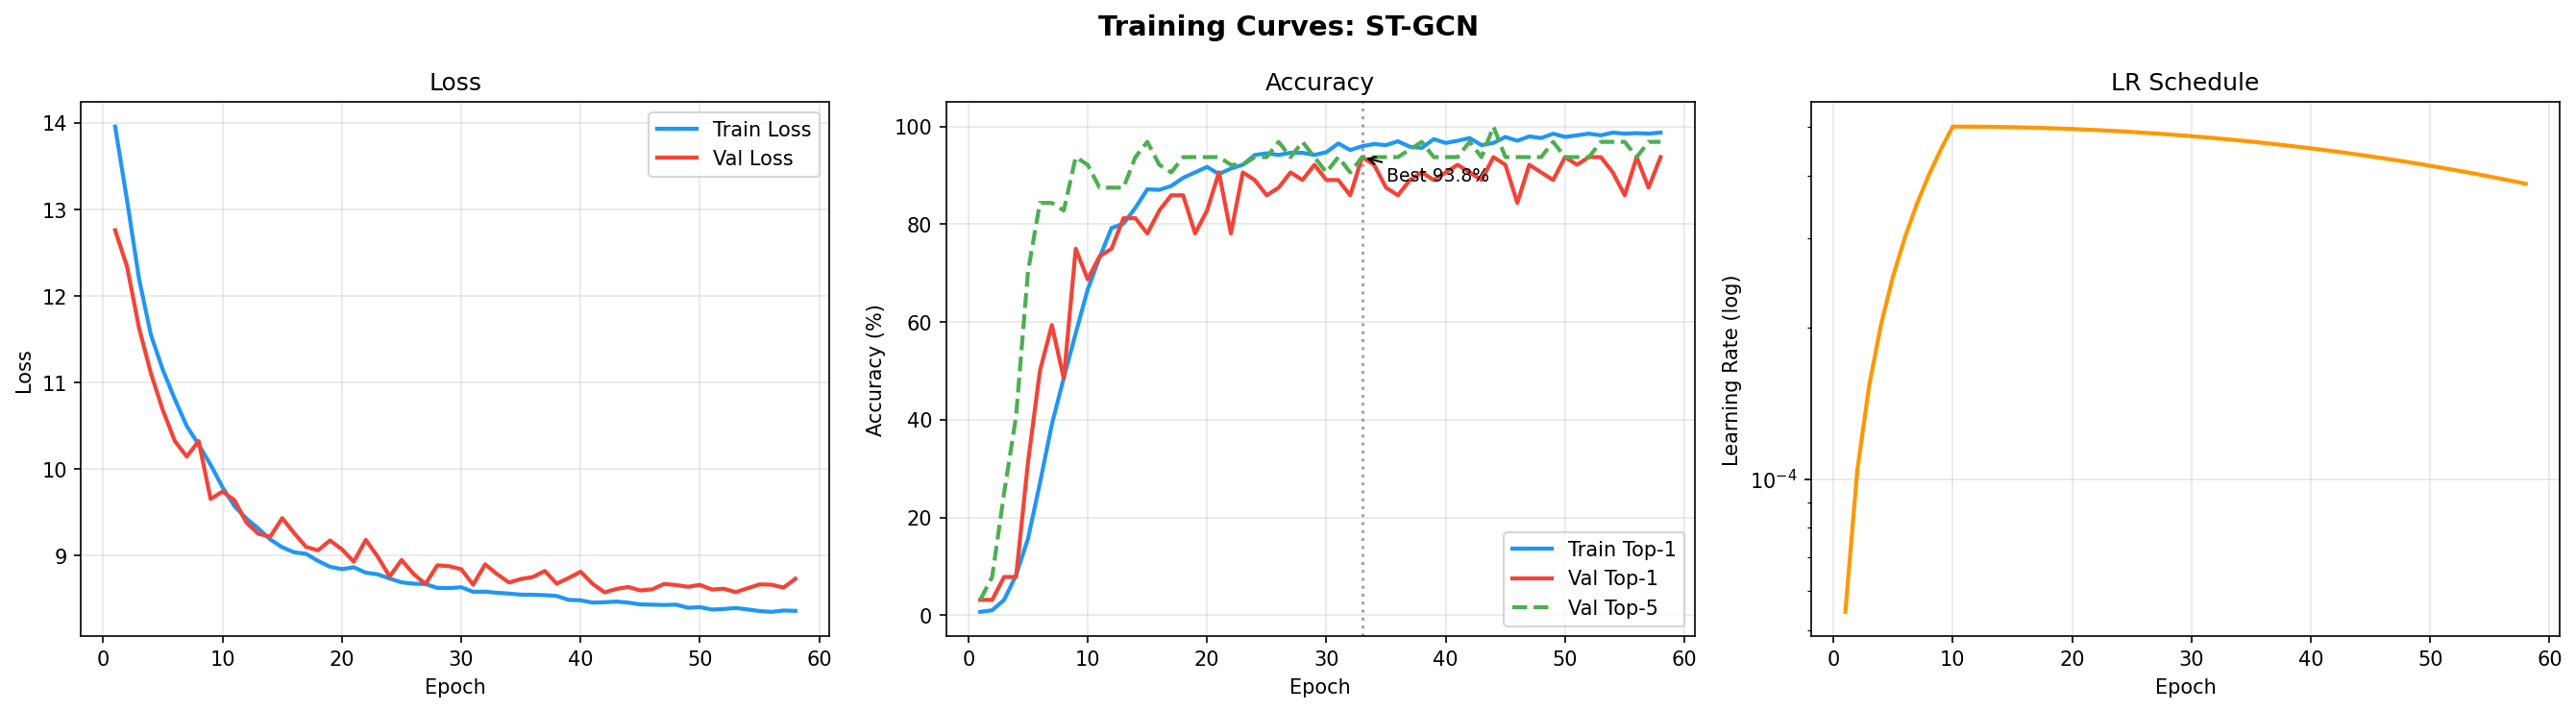

In [ ]:
from IPython.display import Image, display

image_path = './results/exp_stgcn/training_curves.png'
display(Image(filename=image_path))

### Model Comparison

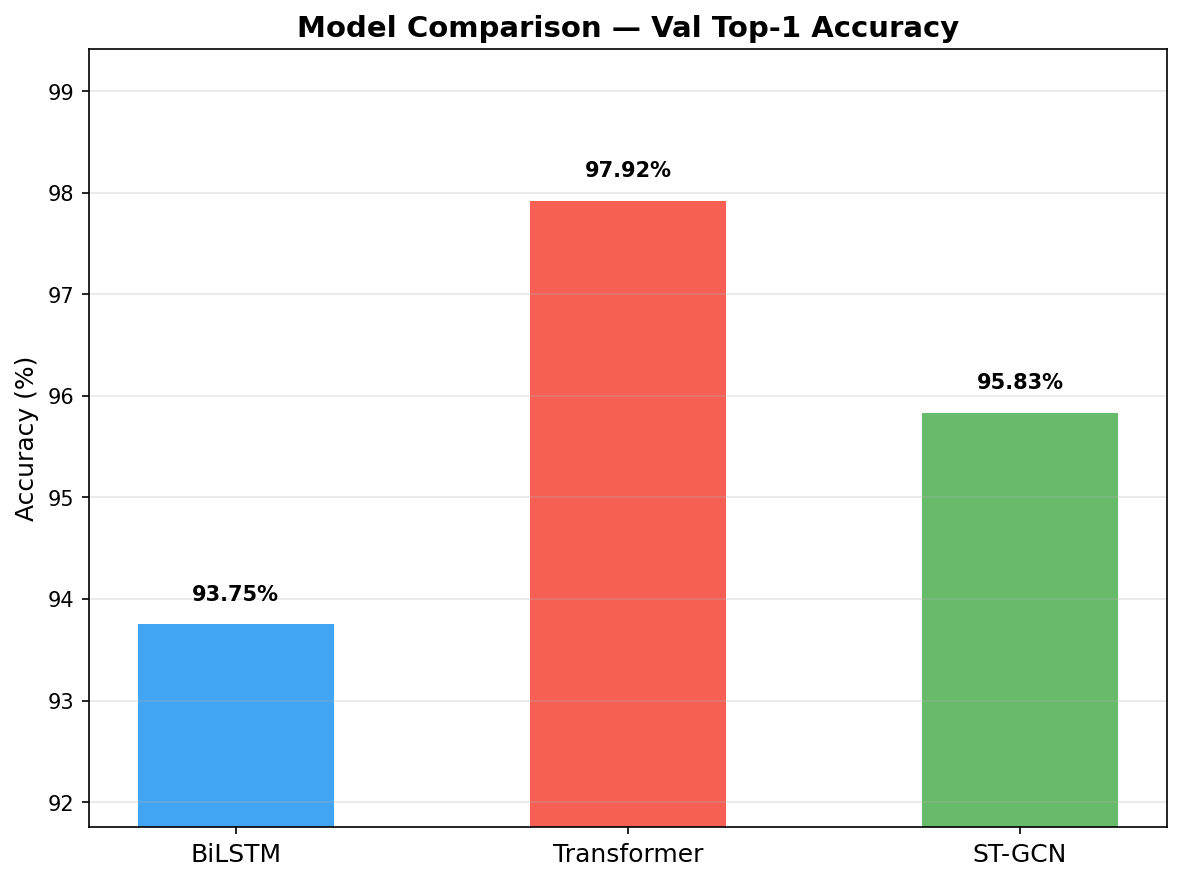

In [ ]:
from IPython.display import Image, display

image_path = './results/comparison_val.png'
display(Image(filename=image_path, width=400, height=200))

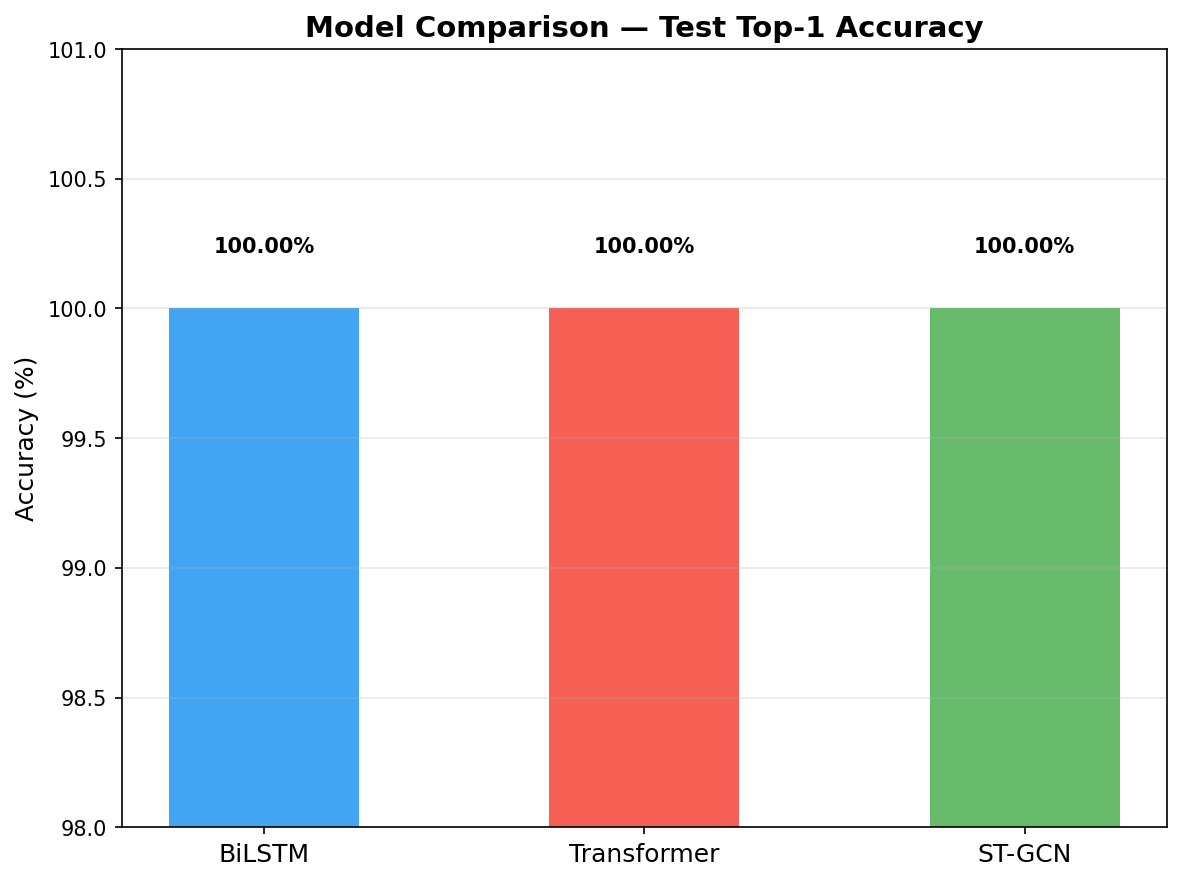

In [ ]:
from IPython.display import Image, display

image_path = './results/comparison_test.png'
display(Image(filename=image_path, width=400, height=200))

In [ ]:
!python ./scripts/compare_results.py

          Model Performance Comparison (Myanmar Sign Language)
Model         | Val Top-1 Val Top-5   Val F1 | Test Top-1 Test Top-5  Test Prec  Test Rec  Test F1
──────────────────────────────────────────────────────────────────────────────────────────────────
Bi-LSTM       |    93.75%    97.92%   91.67% |    100.00%    100.00%    100.00%   100.00%  100.00%
Transformer   |    97.92%    97.92%   97.22% |    100.00%    100.00%    100.00%   100.00%  100.00%
ST-GCN        |    95.83%    95.83%   94.44% |    100.00%    100.00%    100.00%   100.00%  100.00%
